In [1]:
#%%
from scipy.stats import norm
import camb
from camb.sources import SplinedSourceWindow
from camb import model
from astropy.cosmology import Planck13, z_at_value
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline
from collections import defaultdict
from scipy.optimize import curve_fit
import pandas as pd
import healpy as hp
import os
import gwbench.basic_relations as brs
from gwbench import Network, injections_CBC_params_redshift, M_of_Mc_eta, f_isco_Msolar, mass_sampler, spin_sampler, get_Mc_eta

import pymaster as nmt
import random
from scipy.special import erf
from astropy.cosmology import FlatLambdaCDM
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy.interpolate import RectBivariateSpline
from scipy.integrate import quad
from scipy import stats
import pickle
from scipy.integrate import simpson
import glob
from scipy.interpolate import UnivariateSpline
import sys 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from gwbench import network
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import corner
import emcee
from scipy.special import ndtr
import jax
import jax.numpy as jnp
from jax import jit, vmap
from jax.scipy.stats import norm
import jax_cosmo as jc

from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import seaborn as sns
from dynesty import NestedSampler, DynamicNestedSampler
from dynesty.utils import resample_equal

from tqdm import tqdm
from matplotlib.lines import Line2D



np.random.seed(42)


/Users/maddycrossparkin/miniconda3/envs/maddyenv_local/lib/python3.12/site-packages/gwbench/basic_relations.py:20: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import GreenwichMeanSiderealTime
/Users/maddycrossparkin/miniconda3/envs/maddyenv_local/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as e

In [ ]:
#%%
import argparse
import numpy as np
import pandas as pd
import emcee
from scipy.integrate import quad
from scipy.special import erf
from astropy.cosmology import FlatLambdaCDM
from tqdm import tqdm
from scipy import integrate
from scipy.interpolate import interp1d
import pickle
import sys
import json
import matplotlib.pyplot as plt


In [31]:

master_filename = (
    "/Users/maddycrossparkin/Downloads/"
    "MICECAT_master_zmax0p7.csv.bz2"
)

data_MICECAT = pd.read_csv(
    master_filename,
    compression="bz2",
)


In [3]:

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']

plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 12

In [ ]:

def add_r_gmr_percentile_columns(data):
    data = data.copy()
    cosmo = FlatLambdaCDM(H0=70.0, Om0=0.25)

    z = data["z"].to_numpy(dtype=float)
    mag_r = data["abs_mag_r"].to_numpy(dtype=float)#data["r_des_true"].to_numpy(dtype=float)
    colour_gmr = data["colour_gmr"].to_numpy(dtype=float)

    F_r = np.nan_to_num(10.0 ** (-0.4 * mag_r), nan=0.0, posinf=0.0, neginf=0.0)

    F_r_sorted = np.sort(F_r[np.isfinite(F_r)])
    F_gmr_sorted = np.sort(colour_gmr[np.isfinite(colour_gmr)])

    if len(F_r_sorted) == 0:
        raise ValueError("No valid r-band flux values in reference catalogue.")

    if len(F_gmr_sorted) == 0:
        raise ValueError("No valid g-r colour values in reference catalogue.")

    F_r_left = np.searchsorted(F_r_sorted, F_r, side="left")
    F_r_right = np.searchsorted(F_r_sorted, F_r, side="right")
    F_r_percentile = 50.0 * (F_r_left + F_r_right) / len(F_r_sorted)

    F_gmr_percentile = np.zeros_like(colour_gmr, dtype=float)
    valid_gmr = np.isfinite(colour_gmr)
    F_gmr_left = np.searchsorted(F_gmr_sorted, colour_gmr[valid_gmr], side="left")
    F_gmr_right = np.searchsorted(F_gmr_sorted, colour_gmr[valid_gmr], side="right")
    F_gmr_percentile[valid_gmr] = 50.0 * (F_gmr_left + F_gmr_right) / len(F_gmr_sorted)
    data["M_r"] = data["abs_mag_r"].to_numpy(dtype=float)

    data["F_r_percentile"] = F_r_percentile
    data["F_gmr_percentile"] = F_gmr_percentile

    return data

data_MICECAT = add_r_gmr_percentile_columns(data_MICECAT)


def sample_gw_f_gmr(f, Ndet, network_name, seed, sigma_zi, snr_thr=8.0, zcut_rate=0.7, n_selection_target=5000, H0_ref=70.0, H0_max_selection=100.0):
    cosmo = FlatLambdaCDM(H0=70.0, Om0=0.25)

    if network_name == "asharp":
        NETWORK_SPEC = ["A#_H", "A#_L", "A#_V"]
    elif network_name == "advanced":
        NETWORK_SPEC = ["aLIGO_H", "aLIGO_L", "aLIGO_V"]
    else:
        raise ValueError("network_name must be 'asharp' or 'advanced'.")

    DERIV_SYMBS = "Mc eta chi1z chi2z DL tc phic iota ra dec psi"
    FREQ_ARRAY = np.arange(10.0, 1024.0, 1.0 / 4.0)

    def get_net_snr(net):
        snr_attr = getattr(net, "snr", np.nan)

        if snr_attr is None:
            snr_net = np.nan
        else:
            try:
                snr_net = float(snr_attr)
            except (TypeError, ValueError):
                snr_net = np.nan

        if not np.isfinite(snr_net):
            snr_vals = []
            if hasattr(net, "detectors"):
                detectors = net.detectors
                det_iter = detectors.values() if isinstance(detectors, dict) else detectors

                for det in det_iter:
                    det_snr = getattr(det, "snr", np.nan)
                    if det_snr is None:
                        continue
                    try:
                        det_snr = float(det_snr)
                    except (TypeError, ValueError):
                        continue
                    if np.isfinite(det_snr):
                        snr_vals.append(det_snr)

            snr_net = float(np.sqrt(np.sum(np.asarray(snr_vals) ** 2))) if len(snr_vals) > 0 else np.nan

        return snr_net

    def run_injection_snr_only(inj_params):
        net = network.Network(NETWORK_SPEC)
        net.set_logger_level("ERROR")
        net.set_net_vars(wf_model_name="tf2", f=FREQ_ARRAY, inj_params=inj_params, deriv_symbs_string=DERIV_SYMBS, conv_log=("DL", "Mc"))
        net.setup_ant_pat_lpf_psds()
        net.calc_wf_polarizations()
        net.calc_det_responses()

        if hasattr(net, "calc_snrs"):
            net.calc_snrs()
        elif hasattr(net, "calc_snr"):
            net.calc_snr()

        return get_net_snr(net)

    def run_injection_full_errors(inj_params):
        net = network.Network(NETWORK_SPEC)
        net.set_logger_level("ERROR")
        net.set_net_vars(wf_model_name="tf2", f=FREQ_ARRAY, inj_params=inj_params, deriv_symbs_string=DERIV_SYMBS, conv_log=("DL", "Mc"))
        net.setup_ant_pat_lpf_psds()
        net.calc_wf_polarizations()
        net.calc_det_responses()
        net.calc_errors(only_net=1, derivs="num", cond_sup=1e12)
        return net

    def build_host_probabilities(galaxies_df, f):
        F_r = galaxies_df["F_r_percentile"].to_numpy(dtype=float)
        F_gmr = galaxies_df["F_gmr_percentile"].to_numpy(dtype=float)
        host_weight = f * F_r + (1.0 - f) * F_gmr
        host_weight = np.maximum(host_weight, 0.0)

        if host_weight.sum() <= 0.0:
            return np.ones(len(galaxies_df), dtype=float) / len(galaxies_df)

        return host_weight / host_weight.sum()

    def sample_injection_from_mock(galaxies_df, cosmo, rng, p_host):
        idx = rng.choice(len(galaxies_df), p=p_host)
        host = galaxies_df.iloc[idx]
        host_idx = int(host.name)
        ra_deg = float(host["ra"])
        dec_deg = float(host["dec"])
        z = float(host["z"])
        DL = float(cosmo.luminosity_distance(z).to(u.Mpc).value)

        seeds = rng.integers(0, 1_000_000, size=2)
        spin_dict = {"dim": 1, "geom": "cartesian", "chi_lo": -0.05, "chi_hi": 0.05}
        chi1x, chi1y, chi1z, chi2x, chi2y, chi2z = spin_sampler(spin_dict, 1, int(seeds[1]))

        chi1z = float(np.atleast_1d(chi1z)[0])
        chi2z = float(np.atleast_1d(chi2z)[0])

        iota = float(np.arccos(rng.uniform(-1.0, 1.0)))
        iota = float(np.clip(iota, 0.05, np.pi - 0.05))
        psi = float(rng.uniform(0.0, 2.0 * np.pi))
        phic = float(rng.uniform(0.0, 2.0 * np.pi))

        Mc = rng.uniform(10.0, 50.0)
        eta = rng.uniform(0.10, 0.24)

        return {
            "host_idx": host_idx,
            "Mc": float(Mc),
            "eta": float(eta),
            "chi1z": chi1z,
            "chi2z": chi2z,
            "DL": DL,
            "tc": 0.0,
            "phic": phic,
            "iota": iota,
            "ra": np.deg2rad(ra_deg),
            "dec": np.deg2rad(dec_deg),
            "psi": psi,
            "z": z,
            "ra_deg": ra_deg,
            "dec_deg": dec_deg,
            "F_r": float(host["F_r_percentile"]),
            "F_gmr": float(host["F_gmr_percentile"]),
        }

    rng = np.random.default_rng(seed=seed)
    data_rate_cut = data_MICECAT[data_MICECAT["z"] <= zcut_rate].copy()

    p_host_true = build_host_probabilities(data_rate_cut, f=f)
    p_selection_ref = np.ones(len(data_rate_cut), dtype=float) / len(data_rate_cut)

    gw_obs_dl = []
    gw_sigma_lnDL = []
    gw_ra = []
    gw_dec = []
    gw_true_z = []
    gw_area_deg2 = []
    gw_snr = []
    gw_rho_times_dl = []
    gw_true_dl = []
    gw_log_dl_noise = []

    prop_z = []
    prop_dl = []
    prop_snr = []
    prop_rho_times_dl = []
    prop_pass_snr = []
    prop_pass_full = []
    prop_pass_final = []
    prop_fail_code = []

    sel_z = []
    sel_dl = []
    sel_F_r = []
    sel_F_gmr = []
    sel_snr = []
    sel_rho_times_dl = []
    sel_fail_code = []
    gw_host_idx = []
    
    n_attempted_gw = 0
    n_attempted_sel = 0
    n_runtime_failed = 0
    n_error_failed = 0
    n_snr_failed = 0

    def record_proposal(z_true, DL_true, snr_net=np.nan, rho_times_dl=np.nan, pass_snr=False, pass_full=False, pass_final=False, fail_code=""):
        prop_z.append(float(z_true))
        prop_dl.append(float(DL_true))
        prop_snr.append(float(snr_net) if np.isfinite(snr_net) else np.nan)
        prop_rho_times_dl.append(float(rho_times_dl) if np.isfinite(rho_times_dl) else np.nan)
        prop_pass_snr.append(bool(pass_snr))
        prop_pass_full.append(bool(pass_full))
        prop_pass_final.append(bool(pass_final))
        prop_fail_code.append(str(fail_code))

    pbar = tqdm(total=Ndet, desc=f"Simulating {network_name} detected GW events", unit="accepted event", leave=True)

    try:
        while len(gw_obs_dl) < Ndet:
            n_attempted_gw += 1
            inj_params = sample_injection_from_mock(galaxies_df=data_rate_cut, cosmo=cosmo, rng=rng, p_host=p_host_true)

            z_true = float(inj_params["z"])
            DL_true = float(inj_params["DL"])
            ra_true = float(inj_params["ra_deg"])
            dec_true = float(inj_params["dec_deg"])

            try:
                snr_net = run_injection_snr_only(dict(inj_params))
            except RuntimeError:
                n_runtime_failed += 1
                record_proposal(z_true, DL_true, fail_code="runtime_snr")
                continue

            if not np.isfinite(snr_net) or snr_net <= 0.0:
                n_error_failed += 1
                record_proposal(z_true, DL_true, snr_net=snr_net, fail_code="invalid_snr")
                continue

            rho_times_dl = float(snr_net * DL_true)

            if snr_net < snr_thr:
                n_snr_failed += 1
                record_proposal(z_true, DL_true, snr_net=snr_net, rho_times_dl=rho_times_dl, pass_snr=False, fail_code="below_snr_thr")
                pbar.set_postfix(attempts=n_attempted_gw, accepted=len(gw_obs_dl), rate=f"{len(gw_obs_dl) / n_attempted_gw:.3f}")
                continue

            try:
                net = run_injection_full_errors(dict(inj_params))
            except RuntimeError:
                n_runtime_failed += 1
                record_proposal(z_true, DL_true, snr_net=snr_net, rho_times_dl=rho_times_dl, pass_snr=True, fail_code="runtime_fisher")
                continue

            sigma_lnDL_raw = net.errs.get("log_DL", np.nan)
            sky_area_raw = net.errs.get("sky_area_90", np.nan)

            sigma_lnDL = np.nan if sigma_lnDL_raw is None else float(sigma_lnDL_raw)
            sky_area = np.nan if sky_area_raw is None else float(sky_area_raw)

            if not np.isfinite(sigma_lnDL) or sigma_lnDL <= 0.0 or not np.isfinite(sky_area) or sky_area <= 0.0:
                n_error_failed += 1
                continue

            eps_draw = float(rng.normal(loc=0.0, scale=sigma_lnDL))
            DL_obs = float(DL_true * np.exp(eps_draw))

            record_proposal(z_true, DL_true, snr_net=snr_net, rho_times_dl=rho_times_dl, pass_snr=True, pass_full=True, pass_final=True, fail_code="accepted")

            gw_obs_dl.append(DL_obs)
            gw_sigma_lnDL.append(sigma_lnDL)
            gw_ra.append(ra_true)
            gw_dec.append(dec_true)
            gw_true_z.append(z_true)
            gw_true_dl.append(DL_true)
            gw_log_dl_noise.append(eps_draw)
            gw_area_deg2.append(sky_area)
            gw_snr.append(float(snr_net))
            gw_rho_times_dl.append(rho_times_dl)
            gw_host_idx.append(int(inj_params["host_idx"]))
            pbar.update(1)
            pbar.set_postfix(attempts=n_attempted_gw, accepted=len(gw_obs_dl), rate=f"{len(gw_obs_dl) / n_attempted_gw:.3f}")

    finally:
        pbar.close()

    # ============================================================
    # Selection MC: store both SNR and Fisher-quality information.
    # IMPORTANT: every selection draw is stored. Draws below SNR get
    # sigma_lnDL = nan and valid_fisher = False.
    # ============================================================

    pbar_sel = tqdm(total=n_selection_target, desc=f"Building {network_name} selection MC", unit="selection draw", leave=True)

    try:
        while len(sel_z) < n_selection_target:
            n_attempted_sel += 1

            inj_params = sample_injection_from_mock(galaxies_df=data_rate_cut, cosmo=cosmo, rng=rng, p_host=p_selection_ref)

            z_true = float(inj_params["z"])
            DL_true = float(inj_params["DL"])
            F_r_true = float(inj_params["F_r"])
            F_gmr_true = float(inj_params["F_gmr"])

            snr_net = np.nan
            rho_times_dl = np.nan
            fail_code = ""

            try:
                snr_net = run_injection_snr_only(dict(inj_params))
            except RuntimeError:
                fail_code = "runtime_snr"

            if np.isfinite(snr_net) and snr_net > 0.0:
                rho_times_dl = float(snr_net * DL_true)
                fail_code = "detected_at_ref" if snr_net >= snr_thr else "below_snr_thr"
            elif fail_code == "":
                fail_code = "invalid_snr"
            

            sel_z.append(z_true)
            sel_dl.append(DL_true)
            sel_F_r.append(F_r_true)
            sel_F_gmr.append(F_gmr_true)
            sel_snr.append(float(snr_net) if np.isfinite(snr_net) else np.nan)
            sel_rho_times_dl.append(float(rho_times_dl) if np.isfinite(rho_times_dl) else np.nan)
            sel_fail_code.append(str(fail_code))

            pbar_sel.update(1)
            pbar_sel.set_postfix(attempts=n_attempted_sel, kept=len(sel_z))

    finally:
        pbar_sel.close()

    print(
        f"\nCompleted {len(gw_obs_dl)} accepted events from {n_attempted_gw} detected-event attempts\n"
        f"Detected-event acceptance rate: {len(gw_obs_dl) / n_attempted_gw:.3%}\n"
        f"Selection MC size: {len(sel_z)} from {n_attempted_sel} selection attempts\n"
        f"Rejected due to runtime errors: {n_runtime_failed}\n"
        f"Rejected due to invalid Fisher/SNR errors: {n_error_failed}\n"
        f"Rejected because snr < {snr_thr:.1f}: {n_snr_failed}"
    )

    gw_catalogue = {
        "gw_host_idx": np.asarray(gw_host_idx, dtype=int),
        "gw_obs_dl": np.asarray(gw_obs_dl),
        "gw_true_dl": np.asarray(gw_true_dl),
        "gw_log_dl_noise": np.asarray(gw_log_dl_noise),
        "gw_sigma_lnDL": np.asarray(gw_sigma_lnDL),
        "gw_area_deg2": np.asarray(gw_area_deg2),
        "gw_true_z": np.asarray(gw_true_z),
        "gw_ra": np.asarray(gw_ra),
        "gw_dec": np.asarray(gw_dec),
        "gw_snr": np.asarray(gw_snr),
        "gw_rho_times_dl": np.asarray(gw_rho_times_dl),
        "snr_thr": float(snr_thr),
        "proposal_z": np.asarray(prop_z),
        "proposal_dl": np.asarray(prop_dl),
        "proposal_snr": np.asarray(prop_snr),
        "proposal_rho_times_dl": np.asarray(prop_rho_times_dl),
        "proposal_pass_snr": np.asarray(prop_pass_snr, dtype=bool),
        "proposal_pass_full": np.asarray(prop_pass_full, dtype=bool),
        "proposal_pass_final": np.asarray(prop_pass_final, dtype=bool),
        "proposal_fail_code": np.asarray(prop_fail_code, dtype=object),
    }

    selection_catalogue = {
        "z": np.asarray(sel_z),
        "DL": np.asarray(sel_dl),
        "F_r": np.asarray(sel_F_r),
        "F_gmr": np.asarray(sel_F_gmr),
        "snr": np.asarray(sel_snr),
        "rho_times_dl": np.asarray(sel_rho_times_dl),
        "fail_code": np.asarray(sel_fail_code, dtype=object),
        "snr_thr": float(snr_thr),
        "host_model": "uniform_galaxies",
        "f_ref": f,
    }

    return gw_catalogue, selection_catalogue


def localisation_area_to_sigma_deg(loc_area, credible_level=0.90):
    radius_deg = np.sqrt(loc_area / np.pi)
    sigma_deg = radius_deg / np.sqrt(-2.0 * np.log(1.0 - credible_level))
    return sigma_deg


def filter_gaussian_localisation(data, loc_area, ra, dec, credible_level=0.90, n_sigma=4.0):
    ra_rad = np.radians(ra)
    dec_rad = np.radians(dec)

    cos_angle = np.sin(np.radians(data["dec"])) * np.sin(dec_rad) + np.cos(np.radians(data["dec"])) * np.cos(dec_rad) * np.cos(np.radians(data["ra"]) - ra_rad)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    angular_distance_deg = np.asarray(np.degrees(np.arccos(cos_angle)), dtype=float)

    sigma_deg = localisation_area_to_sigma_deg(loc_area, credible_level=credible_level)
    keep = angular_distance_deg <= n_sigma * sigma_deg

    filtered_data = data[keep]
    theta_deg = angular_distance_deg[keep]
    sky_weight = np.exp(-0.5 * (theta_deg / sigma_deg) ** 2)

    return filtered_data, sky_weight


def prepare_mice_data(data, loc_area, ra, dec, zcut_rate=0.7, ):
    if zcut_rate is not None:
        data = data[data["z"] <= zcut_rate]

    cone_mice, sky_weight = filter_gaussian_localisation( data=data, loc_area=loc_area, ra=ra, dec=dec,)

    z_arr = cone_mice["z"].to_numpy(dtype=float)
    F_r = cone_mice["F_r_percentile"].to_numpy(dtype=float)
    F_gmr = cone_mice["F_gmr_percentile"].to_numpy(dtype=float)
    gal_idx = cone_mice.index.to_numpy()

    return z_arr, F_r, F_gmr, sky_weight, gal_idx

def LGW_lognormal(dL_obs, dL_true, sigma_lnDL):
    dL_true = np.asarray(dL_true, dtype=float)

    if dL_obs <= 0.0 or sigma_lnDL <= 0.0:
        return np.zeros_like(dL_true)

    log_ratio = (np.log(dL_obs) - np.log(dL_true)) / sigma_lnDL
    likelihood = np.exp(-0.5 * log_ratio**2) / (np.sqrt(2.0 * np.pi) * sigma_lnDL * dL_obs)

    return likelihood


def prepare_events_for_mcmc(gw_catalogue, data_MICECAT, sigma_zi, seed,zcut_rate=0.7, max_events=None, batch_size=500, nz_grid=2500):
    rng = np.random.default_rng(seed)

    if "snr_thr" not in gw_catalogue:
        raise KeyError("Store snr_thr in gw_catalogue['snr_thr'].")

    snr_thr = float(gw_catalogue["snr_thr"])
    gw_obs_dl_all = np.asarray(gw_catalogue["gw_obs_dl"], dtype=float)
    gw_sigma_lnDL_all = np.asarray(gw_catalogue["gw_sigma_lnDL"], dtype=float)
    gw_area_deg2_all = np.asarray(gw_catalogue["gw_area_deg2"], dtype=float)
    gw_ra_all = np.asarray(gw_catalogue["gw_ra"], dtype=float)
    gw_dec_all = np.asarray(gw_catalogue["gw_dec"], dtype=float)
    gw_snr_all = np.asarray(gw_catalogue["gw_snr"], dtype=float)
    gw_rho_times_dl_all = np.asarray(gw_catalogue["gw_rho_times_dl"], dtype=float)
    
    nevents = len(gw_obs_dl_all)
    if max_events is not None:
        nevents = min(nevents, max_events)

    cosmo = FlatLambdaCDM(H0=70.0, Om0=0.25)

    zinterpolant = np.exp(np.linspace(np.log(1.0e-4), np.log(zcut_rate), nz_grid))
    dvcdz_ff = cosmo.differential_comoving_volume(zinterpolant).value
    dltimesH0 = cosmo.luminosity_distance(zinterpolant).to("Mpc").value * 70.0

    data_rate_cut = data_MICECAT[data_MICECAT["z"] <= zcut_rate].copy()
    prepared_events = []

    for event_idx in tqdm(range(nevents), desc="Preparing GW events"):
        gw_obs_dl = gw_obs_dl_all[event_idx]
        sigma_lnDL = gw_sigma_lnDL_all[event_idx]
        loc_area = gw_area_deg2_all[event_idx]
        ra = gw_ra_all[event_idx]
        dec = gw_dec_all[event_idx]

        z_arr, F_r, F_gmr, sky_weight, gal_idx = prepare_mice_data( data=data_rate_cut, loc_area=loc_area, ra=ra, dec=dec, zcut_rate=None)
        if len(z_arr) == 0:
            print(f"Skipping event {event_idx}: no galaxies found in localisation region.")
            continue

        sigmaz = sigma_zi * (1.0 + z_arr)
        z_obs = rng.normal(z_arr, sigmaz)

        L_r_grid = np.zeros_like(zinterpolant, dtype=float)
        L_gmr_grid = np.zeros_like(zinterpolant, dtype=float)

        for start in range(0, len(z_obs), batch_size):
            stop = min(start + batch_size, len(z_obs))

            z_obs_batch = z_obs[start:stop]
            sigmaz_batch = sigmaz[start:stop]
            F_r_batch = F_r[start:stop]
            F_gmr_batch = F_gmr[start:stop]
            sky_weight_batch = sky_weight[start:stop]

            dz = (zinterpolant[None, :] - z_obs_batch[:, None]) / sigmaz_batch[:, None]
            gauss = np.exp(-0.5 * dz**2) / (sigmaz_batch[:, None] * np.sqrt(2.0 * np.pi))
            weighted_gauss = gauss * dvcdz_ff[None, :]

            norms = np.trapezoid(weighted_gauss, zinterpolant, axis=1)
            norms = np.where(norms > 0.0, norms, 1.0)
            evals = weighted_gauss / norms[:, None]  
            L_r_grid += np.sum(evals * F_r_batch[:, None] * sky_weight_batch[:, None], axis=0)
            L_gmr_grid += np.sum(evals * F_gmr_batch[:, None] * sky_weight_batch[:, None], axis=0)

            del dz, gauss, weighted_gauss, norms, evals

        prepared_events.append({
            "gal_idx": gal_idx,
            "event_idx": event_idx,
            "loc_area": loc_area,
            "ra": ra,
            "dec": dec,
            "gw_obs_dl": gw_obs_dl,
            "sigma_lnDL": sigma_lnDL,
            "snr_thr": snr_thr,
            "n_galaxies": len(z_arr),
            "z_gal": z_arr,
            "F_r_gal": F_r,
            "F_gmr_gal": F_gmr,
            "sky_weight": sky_weight,
            "zinterpolant": zinterpolant,
            "L_r_grid": L_r_grid,
            "L_gmr_grid": L_gmr_grid,
            "local_base_grid": L_gmr_grid,
            "local_diff_grid": L_r_grid - L_gmr_grid,
            "dltimesH0": dltimesH0,
            "gw_snr": gw_snr_all[event_idx],
            "rho_times_dl": gw_rho_times_dl_all[event_idx],
        })
    print(f"Prepared {len(prepared_events)} of {nevents} GW events.")
    return prepared_events


def log_prior(theta, H0_min=40.0, H0_max=100.0, f_min=0.0, f_max=1.0):
    H0, f = theta
    if not H0_min < H0 < H0_max:
        return -np.inf
    if not 0.0 <= f <= 1.0:
        return -np.inf
    return 0.0


def interpolate_pdet_H0(H0, pdet_model):
    H0_grid = np.asarray(pdet_model["H0_grid"], dtype=float)
    pdet_grid = np.asarray(pdet_model["pdet_grid"], dtype=float)

    pdet = np.array([np.interp(H0, H0_grid, pdet_grid[:, j], left=pdet_grid[0, j], right=pdet_grid[-1, j]) for j in range(pdet_grid.shape[1])])
    return np.clip(pdet, 1.0e-12, 1.0)


def pdet_on_z_grid(H0, z_grid, selection_model):
    pdet_model = selection_model["pdet_model"]
    pdet_bins = interpolate_pdet_H0(H0, pdet_model)
    return np.interp(z_grid, pdet_model["z_centres"], pdet_bins, left=pdet_bins[0], right=pdet_bins[-1])

def alpha_direct(H0, f, selection_catalogue):
    z = np.asarray(selection_catalogue["z"], dtype=float)
    F_r = np.asarray(selection_catalogue["F_r"], dtype=float)
    F_gmr = np.asarray(selection_catalogue["F_gmr"], dtype=float)
    rho_times_dl = np.asarray(selection_catalogue["rho_times_dl"], dtype=float)
    dltimesH0 = np.asarray(selection_catalogue["dltimesH0"], dtype=float)
    snr_thr = float(selection_catalogue["snr_thr"])

    valid = np.isfinite(z) & np.isfinite(F_r) & np.isfinite(F_gmr) & np.isfinite(rho_times_dl) & np.isfinite(dltimesH0) & (rho_times_dl > 0.0) & (dltimesH0 > 0.0)

    w = np.maximum(F_gmr + f * (F_r - F_gmr), 0.0)
    rho_trial = np.full_like(z, np.nan, dtype=float)
    rho_trial[valid] = rho_times_dl[valid] / (dltimesH0[valid] / H0)

    detected = valid & (rho_trial >= snr_thr)

    den = np.sum(w[valid])
    num = np.sum(w[detected])

    if not np.isfinite(num) or not np.isfinite(den) or num <= 0.0 or den <= 0.0:
        return np.nan

    return num / den

def clean_prepared_events(prepared_events):
    return [
        ev for ev in prepared_events
        if np.isfinite(ev["gw_obs_dl"])
        and ev["gw_obs_dl"] > 0.0
        and np.isfinite(ev["sigma_lnDL"])
        and ev["sigma_lnDL"] > 0.0
    ]
    
    
def log_likelihood(theta, prepared_events, selection_catalogue, sigma_max=np.inf,):
    H0, f = theta

    if not 40.0 <= H0 <= 100.0:
        return -np.inf
    if not 0.0 <= f <= 1.0:
        return -np.inf

    alpha = alpha_direct( H0=H0, f=f, selection_catalogue=selection_catalogue,)

    if not np.isfinite(alpha) or alpha <= 0.0:
        return -np.inf

    events = clean_prepared_events(prepared_events)

    if len(events) == 0:
        return -np.inf

    loglike = 0.0
    log_alpha = np.log(alpha)

    for ev in events:
        if ev["sigma_lnDL"] > sigma_max:
            continue

        z = np.asarray(ev["zinterpolant"], dtype=float)

        q = (np.asarray(ev["local_base_grid"], dtype=float) + f * np.asarray(ev["local_diff_grid"], dtype=float))
        q = np.maximum(q, 0.0)

        q_norm = np.trapezoid(q, z)
        if not np.isfinite(q_norm) or q_norm <= 0.0:
            return -np.inf

        q = q / q_norm

        dltrial = np.asarray(ev["dltimesH0"], dtype=float) / H0

        lgw = LGW_lognormal( dL_obs=ev["gw_obs_dl"], dL_true=dltrial, sigma_lnDL=ev["sigma_lnDL"],)
        rho_trial = ev["rho_times_dl"] / dltrial
        event_detectable = (rho_trial >= ev["snr_thr"]).astype(float)

        numerator = np.trapezoid(lgw * q * event_detectable, z)

        if not np.isfinite(numerator) or numerator <= 0.0:
            return -np.inf

        loglike += np.log(numerator) - log_alpha

    return loglike

def log_probability(theta, prepared_events, selection_catalogue, sigma_max=np.inf):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(
        theta=theta,
        prepared_events=prepared_events,
        selection_catalogue=selection_catalogue,
        sigma_max=sigma_max,
    )

    if not np.isfinite(ll):
        return -np.inf

    return lp + ll

def finalise_selection_catalogue(selection_catalogue, zcut_rate=0.7):
    cosmo = FlatLambdaCDM(H0=70.0, Om0=0.25)

    z = np.asarray(selection_catalogue["z"], dtype=float)
    F_r = np.asarray(selection_catalogue["F_r"], dtype=float)
    F_gmr = np.asarray(selection_catalogue["F_gmr"], dtype=float)
    keep = np.isfinite(z) & np.isfinite(F_r) & np.isfinite(F_gmr) & (z > 0.0) & (z <= zcut_rate)

    out = {}

    for key, val in selection_catalogue.items():
        if key in ["snr_thr", "host_model", "f_ref"]:
            continue

        arr = np.asarray(val)

        if arr.shape[0] == len(z):
            out[key] = arr[keep]

    z_keep = out["z"].astype(float)
    out["dltimesH0"] = cosmo.luminosity_distance(z_keep).to("Mpc").value * 70.0

    out["snr_thr"] = float(selection_catalogue["snr_thr"])
    out["host_model"] = selection_catalogue.get("host_model", "unknown")
    out["selection_reference"] = selection_catalogue.get("f_ref", "unknown")

    print(f"Final selection catalogue contains {len(z_keep)} injections with z <= {zcut_rate}.")
    print("valid finite rho:", np.sum(np.isfinite(out["rho_times_dl"]) & (out["rho_times_dl"] > 0.0)))

    return out


def fill_missing_1d(x, y):
    y = np.asarray(y, dtype=float)
    good = np.isfinite(y)

    if np.sum(good) == 0:
        return np.zeros_like(y)

    if np.sum(good) == 1:
        return np.full_like(y, y[good][0])

    return np.interp(x, x[good], y[good], left=y[good][0], right=y[good][-1])


def build_pdet_snr_grid(selection_catalogue, H0_grid, z_edges):
    z_sel = np.asarray(selection_catalogue["z"], dtype=float)
    rho_times_dl = np.asarray(selection_catalogue["rho_times_dl"], dtype=float)
    dltimesH0 = np.asarray(selection_catalogue["dltimesH0"], dtype=float)
    snr_thr = float(selection_catalogue["snr_thr"])

    valid = np.isfinite(z_sel) & np.isfinite(rho_times_dl) & np.isfinite(dltimesH0) & (z_sel > 0.0) & (rho_times_dl > 0.0)
    z_sel = z_sel[valid]
    rho_times_dl = rho_times_dl[valid]
    dltimesH0 = dltimesH0[valid]

    z_centres = 0.5 * (z_edges[:-1] + z_edges[1:])
    n_all, _ = np.histogram(z_sel, bins=z_edges)

    pdet_grid = np.zeros((len(H0_grid), len(z_centres)), dtype=float)

    for i, H0 in enumerate(H0_grid):
        dl_trial = dltimesH0 / H0
        rho_trial = rho_times_dl / dl_trial
        detected = (rho_trial >= snr_thr).astype(float)

        n_det, _ = np.histogram(z_sel, bins=z_edges, weights=detected)

        pdet_bins = np.full_like(n_all.astype(float), np.nan, dtype=float)
        good = n_all > 0
        pdet_bins[good] = n_det[good] / n_all[good]

        pdet_bins = fill_missing_1d(z_centres, pdet_bins)
        pdet_grid[i] = np.clip(pdet_bins, 0.0, 1.0)

    return {
        "H0_grid": np.asarray(H0_grid, dtype=float),
        "z_edges": np.asarray(z_edges, dtype=float),
        "z_centres": z_centres,
        "pdet_grid": pdet_grid,
    }

def build_global_host_hist(data_MICECAT, z_edges, zcut_rate=0.7):
    cosmo = FlatLambdaCDM(H0=70.0, Om0=0.25)

    data_global = data_MICECAT[(data_MICECAT["z"] > z_edges[0]) & (data_MICECAT["z"] <= zcut_rate)].copy()

    z_global = data_global["z"].to_numpy(dtype=float)
    F_r_global = data_global["F_r_percentile"].to_numpy(dtype=float)
    F_gmr_global = data_global["F_gmr_percentile"].to_numpy(dtype=float)

    z_centres = 0.5 * (z_edges[:-1] + z_edges[1:])
    F_r_hist, _ = np.histogram(z_global, bins=z_edges, weights=F_r_global)
    F_gmr_hist, _ = np.histogram(z_global, bins=z_edges, weights=F_gmr_global)

    dltimesH0 = cosmo.luminosity_distance(z_centres).to("Mpc").value * 70.0

    return {
        "z_edges": z_edges,
        "z_centres": z_centres,
        "F_r_hist": F_r_hist,
        "F_gmr_hist": F_gmr_hist,
        "dltimesH0": dltimesH0,
    }

def build_paper_selection_model(data_MICECAT, selection_catalogue, zcut_rate=0.7, H0_min=40.0, H0_max=100.0, nH0=121, nz_pdet=160):
    z_edges = np.linspace(1.0e-4, zcut_rate, nz_pdet + 1)
    H0_grid = np.linspace(H0_min, H0_max, nH0)

    global_host_hist = build_global_host_hist(data_MICECAT=data_MICECAT, z_edges=z_edges, zcut_rate=zcut_rate)
    pdet_model = build_pdet_snr_grid(selection_catalogue=selection_catalogue, H0_grid=H0_grid, z_edges=z_edges)

    return {
        "global_host_hist": global_host_hist,
        "pdet_model": pdet_model,
        "selection_catalogue": selection_catalogue,
    }


def generate_and_save_realisations(f_true, filename, nreals, Ndet, network_name, seed0, sigma_zi, snr_thr, zcut_rate, n_selection_target, nz_grid,):

    results = []

    for r in range(nreals):

        seed = seed0 + r

        print("\n" + "="*70)
        print(f"Generating seed={seed}")
        print("="*70)

        gw_catalogue, selection_catalogue_raw = sample_gw_f_gmr(f = f_true, Ndet=Ndet, network_name=network_name, seed=seed, sigma_zi=sigma_zi, snr_thr=snr_thr, zcut_rate=zcut_rate, n_selection_target=n_selection_target,)

        prepared_events = prepare_events_for_mcmc(
            gw_catalogue=gw_catalogue,
            data_MICECAT=data_MICECAT,
            sigma_zi=sigma_zi,
            seed=seed + 12345,
            zcut_rate=zcut_rate,
            nz_grid=nz_grid,
        )
        
        selection_catalogue = finalise_selection_catalogue(
            selection_catalogue_raw,
            zcut_rate=zcut_rate,
        )

        results.append({
            "seed": seed,
            "gw_catalogue": gw_catalogue,
            "selection_catalogue": selection_catalogue,
            "prepared_events": prepared_events,
        })

        print(f"saved realisation {r+1}/{nreals}")

    with open(filename, "wb") as f:
        pickle.dump(results, f)

    print("\nSaved →", filename)

    return results


In [5]:
import os
import pickle
import numpy as np

Ndets = [1000, 200]
network_names = ["advanced", "asharp"]
f_true = 0.5
nreals = 10
seed0 = 10000

sigma_zi = 1.0e-3
snr_thr = 8.0
zcut_rate = 0.7
nz_grid = 800

n_selection_target_shared = 50000

for network_name in network_names:
    for Ndet in Ndets:

        filename = f"GWPrepared_ftrue{f_true}_sigmaz{sigma_zi}_snr{snr_thr}_{network_name}_{Ndet}_{nreals}reals_FINALAbsMagWeight.pkl"
        shared_selection_filename = f"SharedSelection_{network_name}_{Ndet}_zcut{zcut_rate}_sigmaz{sigma_zi}_snr{snr_thr}_nsel{n_selection_target_shared}_FINALAbsMag.pkl"
        # ============================================================
        # ALWAYS LOAD OR BUILD THE SHARED SELECTION CATALOGUE FIRST
        # ============================================================

        if os.path.exists(shared_selection_filename):
            print(f"\nLoading shared selection catalogue: {shared_selection_filename}")

            with open(shared_selection_filename, "rb") as f:
                shared = pickle.load(f)

            shared_selection_catalogue_raw = shared.get("selection_catalogue_raw", None)
            shared_selection_catalogue = shared["selection_catalogue"]
            shared_selection_model = shared["selection_model"]   # add this

            print("shared selection keys:", shared_selection_catalogue.keys())

        else:
            print("\n" + "=" * 80)
            print(f"Building shared selection catalogue for {network_name}")
            print("=" * 80)

            gw_tmp, selection_catalogue_raw = sample_gw_f_gmr(
                f=f_true,
                Ndet=Ndet,
                network_name=network_name,
                seed=seed0 + 999999,
                sigma_zi=sigma_zi,
                snr_thr=snr_thr,
                zcut_rate=zcut_rate,
                n_selection_target=n_selection_target_shared,
            )

            shared_selection_catalogue = finalise_selection_catalogue(
                selection_catalogue_raw,
                zcut_rate=zcut_rate,
            )

            shared_selection_catalogue_raw = selection_catalogue_raw
            shared_selection_model = build_paper_selection_model(
                data_MICECAT=data_MICECAT,
                selection_catalogue=shared_selection_catalogue,
                zcut_rate=zcut_rate,
                H0_min=40.0,
                H0_max=100.0,
                nH0=121,
                nz_pdet=160,
            )
            shared = {
                "network_name": network_name,
                "zcut_rate": zcut_rate,
                "snr_thr": snr_thr,
                "n_selection_target": n_selection_target_shared,
                "selection_catalogue_raw": shared_selection_catalogue_raw,
                "selection_catalogue": shared_selection_catalogue,
                "selection_model": shared_selection_model,
            }

            with open(shared_selection_filename, "wb") as f:
                pickle.dump(shared, f)

            print(f"Saved shared selection catalogue: {shared_selection_filename}")

        # ============================================================
        # NOW LOAD EXISTING REALISATIONS IF THEY EXIST
        # ============================================================

        if os.path.exists(filename):
            print("\n" + "=" * 80)
            print(f"Loading existing prepared realisations: {filename}")
            print("=" * 80)

            with open(filename, "rb") as f:
                results = pickle.load(f)

            print(f"Loaded {len(results)} realisations from {filename}")
            continue

        # ============================================================
        # OTHERWISE GENERATE ONLY GW EVENTS FOR EACH REALISATION
        # ============================================================

        results = []

        for r in range(nreals):
            seed = seed0 + r

            print("\n" + "=" * 80)
            print(f"{network_name} Ndet={Ndet} seed={seed}")
            print("=" * 80)

            gw_catalogue, _ = sample_gw_f_gmr(
                f=f_true,
                Ndet=Ndet,
                network_name=network_name,
                seed=seed,
                sigma_zi=sigma_zi,
                snr_thr=snr_thr,
                zcut_rate=zcut_rate,
                n_selection_target=0,
            )

            if r == 0:
                print("gw_catalogue keys:", gw_catalogue.keys())

            prepared_events = prepare_events_for_mcmc(
                gw_catalogue=gw_catalogue,
                data_MICECAT=data_MICECAT,
                sigma_zi=sigma_zi,
                seed=seed + 12345,
                zcut_rate=zcut_rate,
                nz_grid=nz_grid,
            )

            if r == 0:
                print("selection_catalogue keys:", shared_selection_catalogue.keys())
                print("prepared event keys:", prepared_events[0].keys())

            results.append({
                "seed": seed,
                "gw_catalogue": gw_catalogue,
                "selection_model": shared_selection_model,
                "selection_catalogue": shared_selection_catalogue,
                "selection_catalogue_raw": shared_selection_catalogue_raw,
                "prepared_events": prepared_events,
            })

            print(f"{network_name} Ndet={Ndet} seed={seed} saved")

        with open(filename, "wb") as f:
            pickle.dump(results, f)

        print(f"\nsaved {filename}")


Loading shared selection catalogue: SharedSelection_advanced_1000_zcut0.7_sigmaz0.001_snr8.0_nsel50000_FINALAbsMag.pkl
shared selection keys: dict_keys(['z', 'DL', 'F_r', 'F_gmr', 'snr', 'rho_times_dl', 'fail_code', 'dltimesH0', 'snr_thr', 'host_model', 'selection_reference'])

Loading existing prepared realisations: GWPrepared_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_10reals_FINALAbsMagWeight.pkl
Loaded 10 realisations from GWPrepared_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_10reals_FINALAbsMagWeight.pkl

Loading shared selection catalogue: SharedSelection_advanced_200_zcut0.7_sigmaz0.001_snr8.0_nsel50000_FINALAbsMag.pkl
shared selection keys: dict_keys(['z', 'DL', 'F_r', 'F_gmr', 'snr', 'rho_times_dl', 'fail_code', 'dltimesH0', 'snr_thr', 'host_model', 'selection_reference'])

Loading existing prepared realisations: GWPrepared_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_10reals_FINALAbsMagWeight.pkl
Loaded 10 realisations from GWPrepared_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_10rea

In [7]:
def run_H0_f_mcmc(
    prepared_events,
    selection_catalogue,
    sigma_max=np.inf,
    H0_start=70.0,
    f_start=0.5,
    seed=12345,
    nwalkers=12,
    nsteps=2000,
    burnin=100,
    thin=1,
):
    rng = np.random.default_rng(seed)

    ndim = 2

    initial_positions = np.zeros((nwalkers, ndim))
    initial_positions[:, 0] = rng.normal(loc=H0_start, scale=0.1, size=nwalkers)
    initial_positions[:, 1] = rng.normal(loc=f_start, scale=0.005, size=nwalkers)

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_probability,
        args=(prepared_events, selection_catalogue, sigma_max),
    )

    sampler.run_mcmc(initial_positions, nsteps, progress=True)

    flat_samples = sampler.get_chain(
        discard=burnin,
        thin=thin,
        flat=True,
    )

    flat_log_prob = sampler.get_log_prob(
        discard=burnin,
        thin=thin,
        flat=True,
    )

    return sampler, flat_samples, flat_log_prob


advanced Ndet=1000
Loading prepared file: GWPrepared_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_10reals_FINALAbsMagWeight.pkl
--------------------------------------------------------------------------------
Realisation 0, seed=10000
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_real0_seed10000_Final.pkl
seed=10000 H0=70.715 +0.655 -0.638 f=0.767 +0.168 -0.260


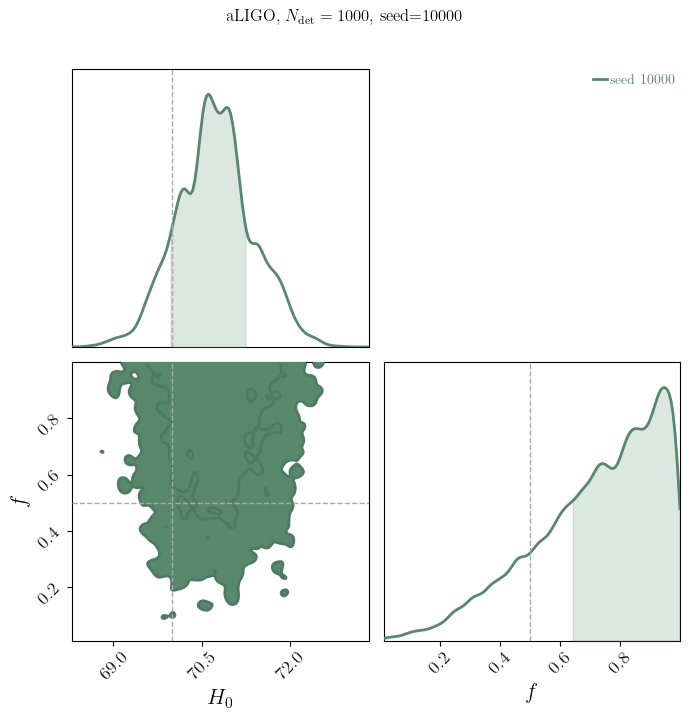

--------------------------------------------------------------------------------
Realisation 1, seed=10001
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_real1_seed10001_Final.pkl
seed=10001 H0=70.454 +0.619 -0.687 f=0.393 +0.250 -0.222


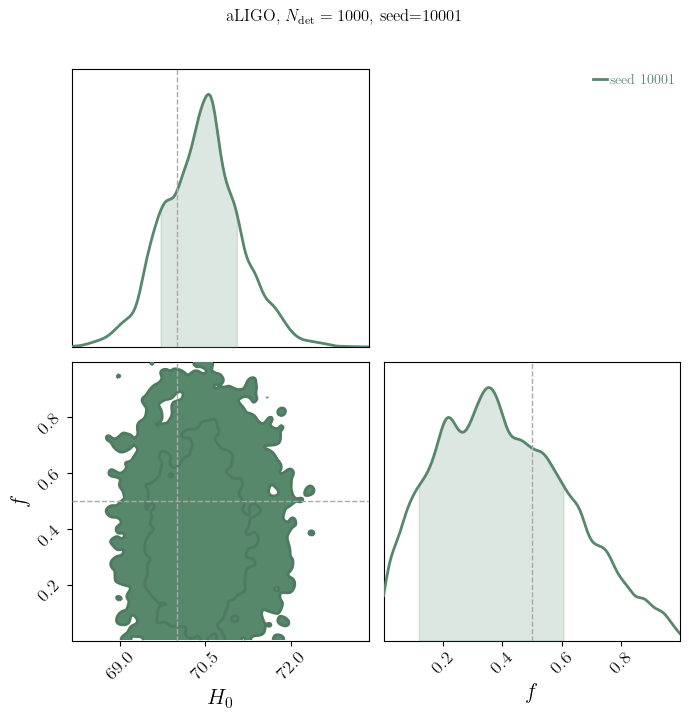

--------------------------------------------------------------------------------
Realisation 2, seed=10002
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_real2_seed10002_Final.pkl
seed=10002 H0=69.547 +0.644 -0.550 f=0.663 +0.225 -0.281


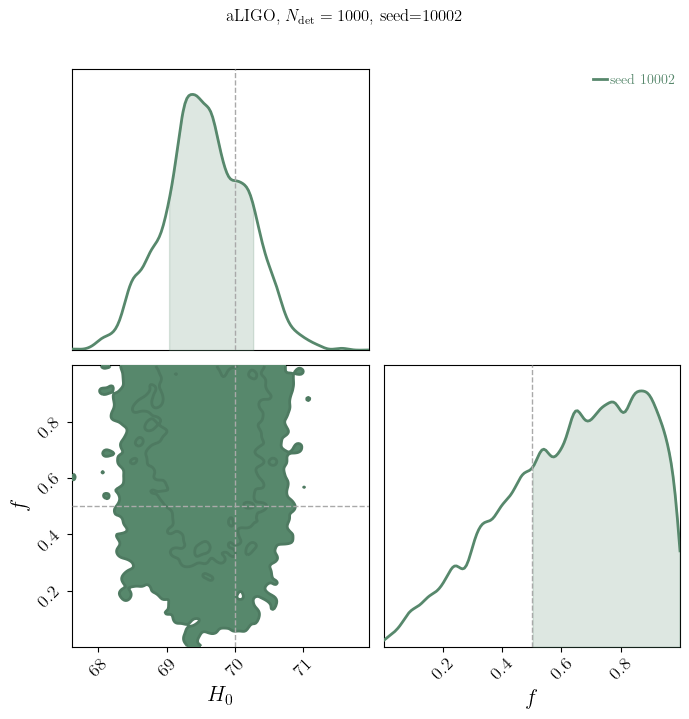

--------------------------------------------------------------------------------
Realisation 3, seed=10003
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_real3_seed10003_Final.pkl
seed=10003 H0=70.212 +0.687 -0.555 f=0.303 +0.240 -0.197


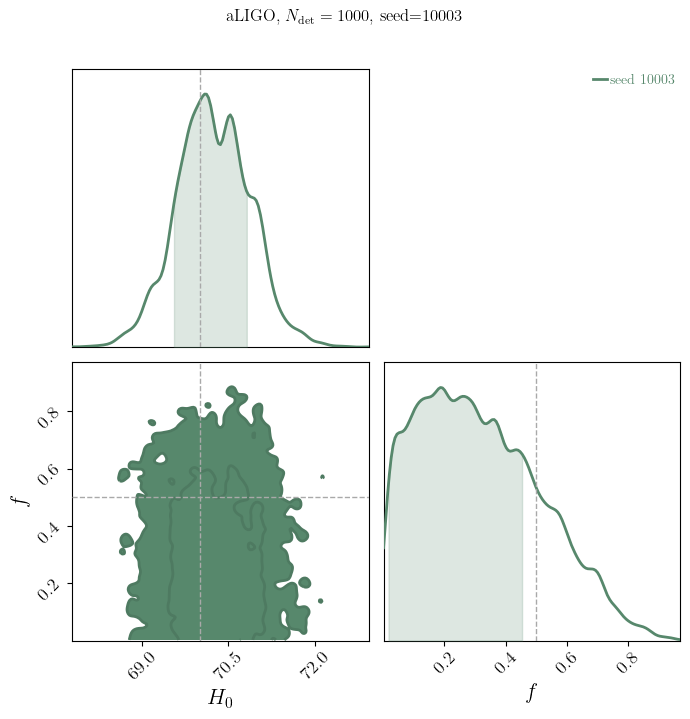

--------------------------------------------------------------------------------
Realisation 4, seed=10004
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_real4_seed10004_Final.pkl
seed=10004 H0=69.963 +0.502 -0.496 f=0.245 +0.241 -0.165


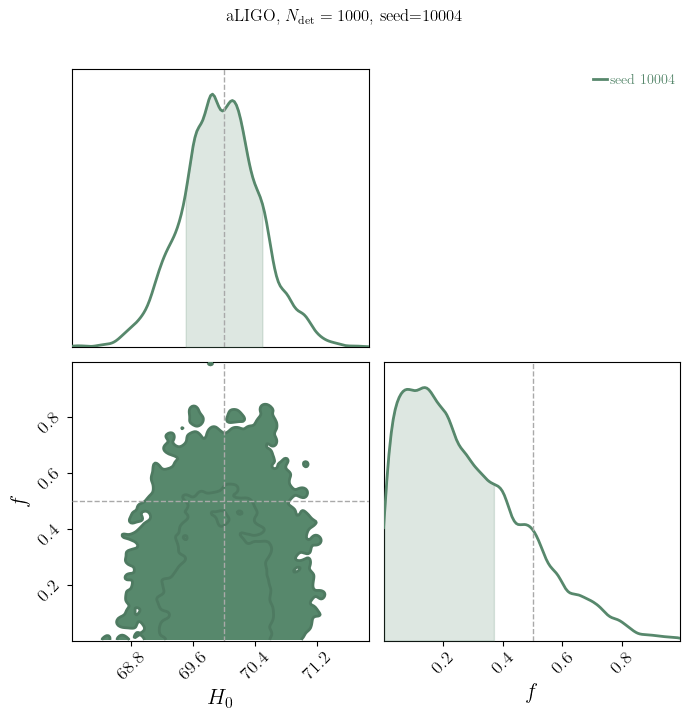

--------------------------------------------------------------------------------
Realisation 5, seed=10005
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_real5_seed10005_Final.pkl
seed=10005 H0=70.760 +0.444 -0.484 f=0.766 +0.154 -0.219


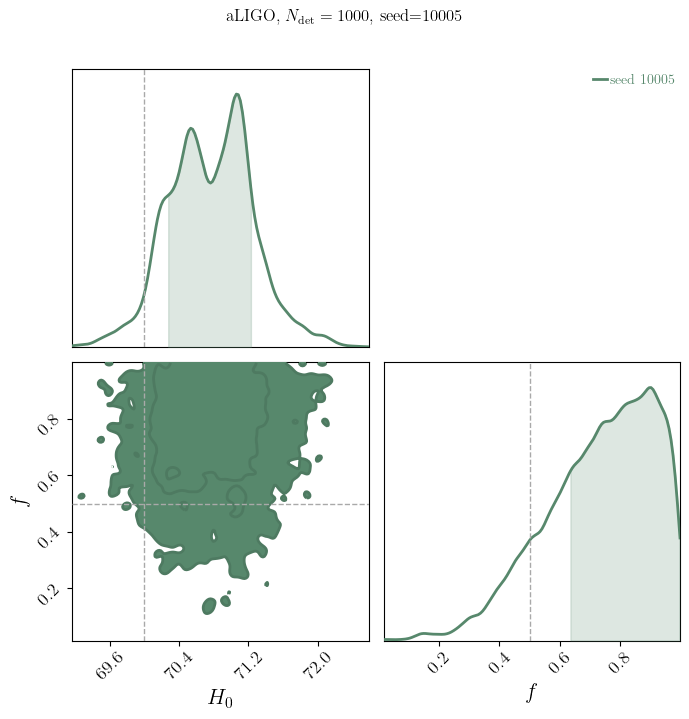

Parameter $H_0$ in chain seed 10006 is not constrained


--------------------------------------------------------------------------------
Realisation 6, seed=10006
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_real6_seed10006_Final.pkl
seed=10006 H0=70.003 +0.710 -0.490 f=0.446 +0.260 -0.244


Parameter $f$ in chain seed 10006 is not constrained


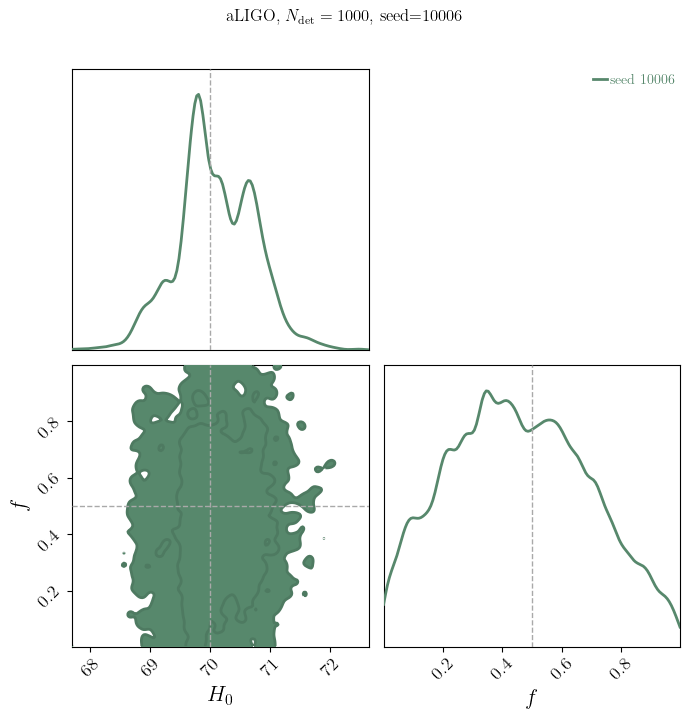

--------------------------------------------------------------------------------
Realisation 7, seed=10007
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_real7_seed10007_Final.pkl
seed=10007 H0=70.010 +0.688 -0.524 f=0.237 +0.255 -0.166


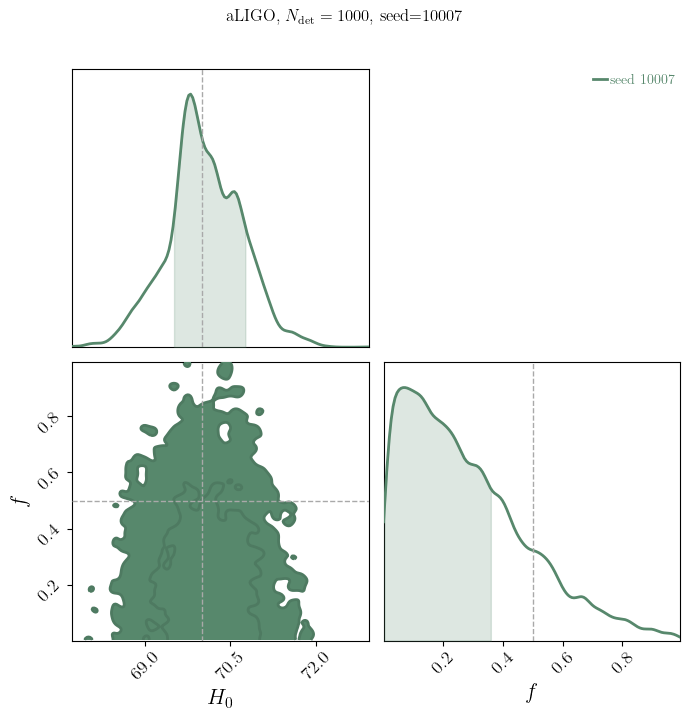

Parameter $H_0$ in chain seed 10008 is not constrained


--------------------------------------------------------------------------------
Realisation 8, seed=10008
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_real8_seed10008_Final.pkl
seed=10008 H0=70.183 +0.461 -0.566 f=0.291 +0.229 -0.180


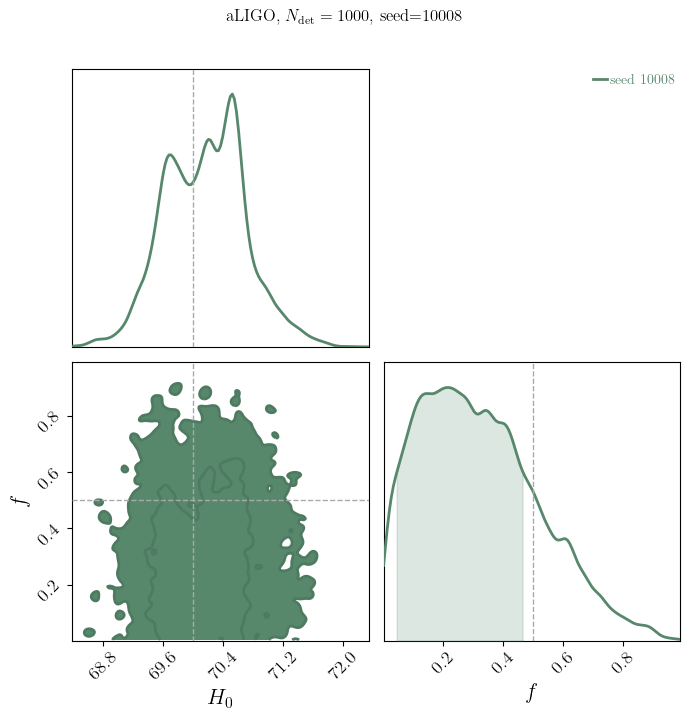

Parameter $f$ in chain seed 10009 is not constrained


--------------------------------------------------------------------------------
Realisation 9, seed=10009
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_real9_seed10009_Final.pkl
seed=10009 H0=70.842 +0.751 -0.600 f=0.504 +0.264 -0.266


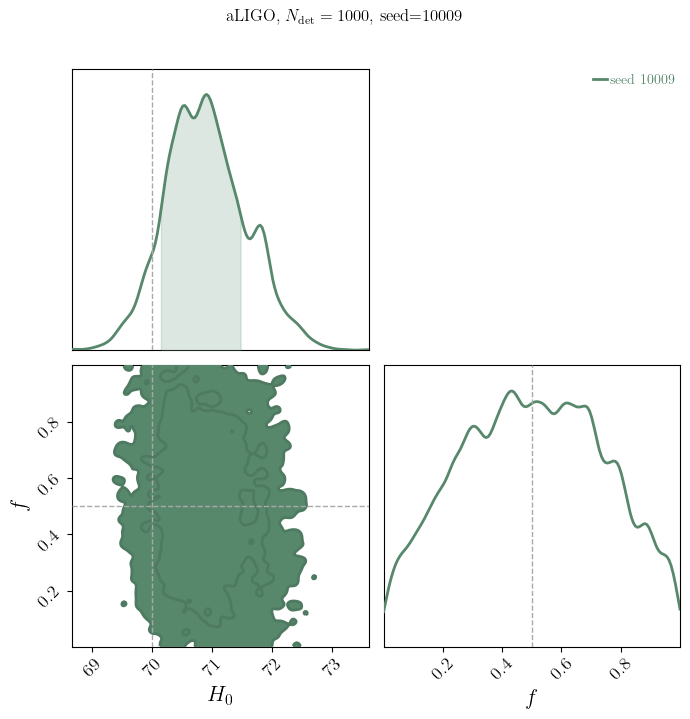

Built 10 KDEs.
Loading existing averaged posterior: AveragePosterior_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_10reals_FINALAbsMagWeight.pkl
--------------------------------------------------------------------------------
AVERAGE H0 = 70.300 +0.568 -0.579
AVERAGE f  = 0.469 +0.248 -0.240

asharp Ndet=1000
Loading prepared file: GWPrepared_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_10reals_FINALAbsMagWeight.pkl
--------------------------------------------------------------------------------
Realisation 0, seed=10000
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_real0_seed10000_Final.pkl
seed=10000 H0=70.072 +0.173 -0.182 f=0.610 +0.138 -0.141


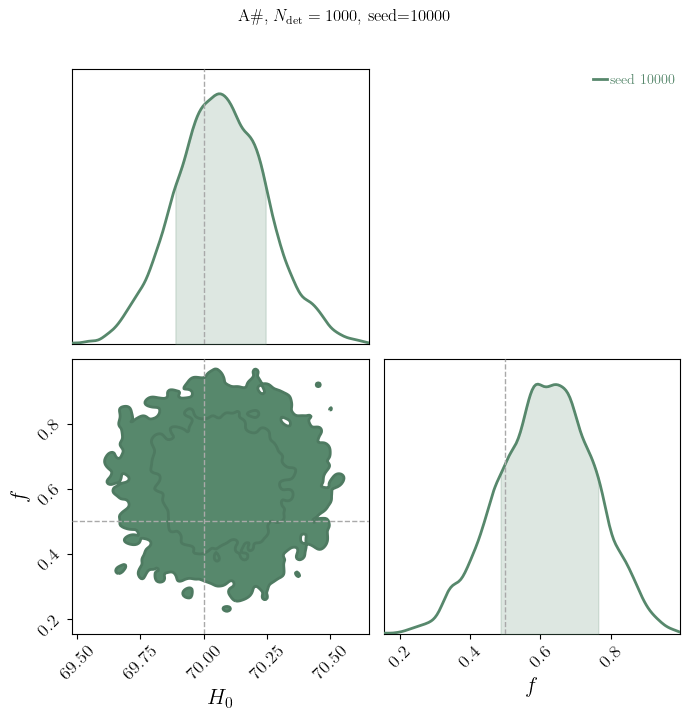

--------------------------------------------------------------------------------
Realisation 1, seed=10001
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_real1_seed10001_Final.pkl
seed=10001 H0=70.188 +0.208 -0.197 f=0.533 +0.135 -0.135


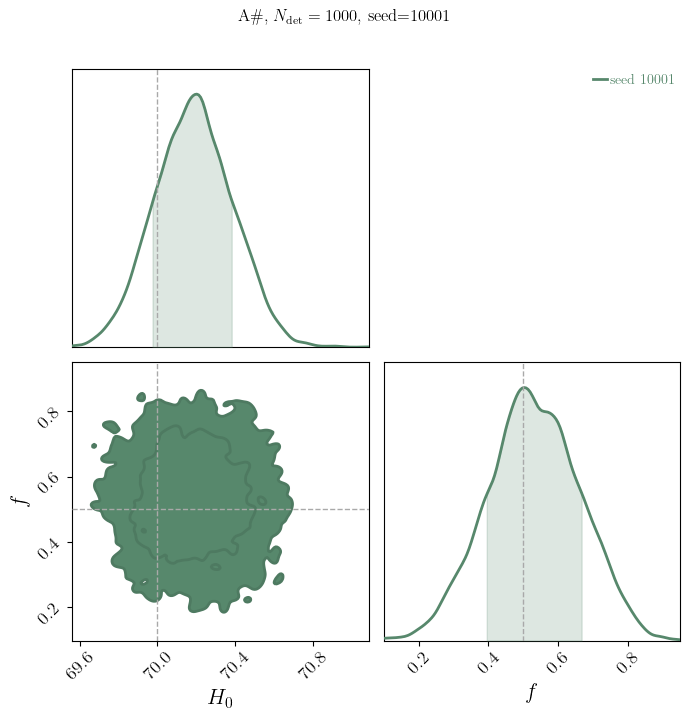

--------------------------------------------------------------------------------
Realisation 2, seed=10002
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_real2_seed10002_Final.pkl
seed=10002 H0=70.106 +0.230 -0.204 f=0.264 +0.148 -0.136


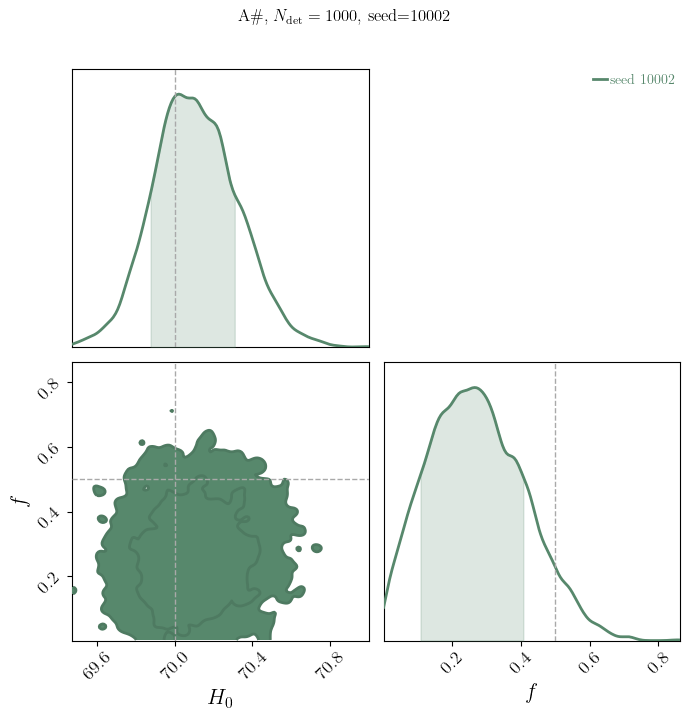

--------------------------------------------------------------------------------
Realisation 3, seed=10003
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_real3_seed10003_Final.pkl
seed=10003 H0=70.016 +0.218 -0.242 f=0.585 +0.131 -0.138


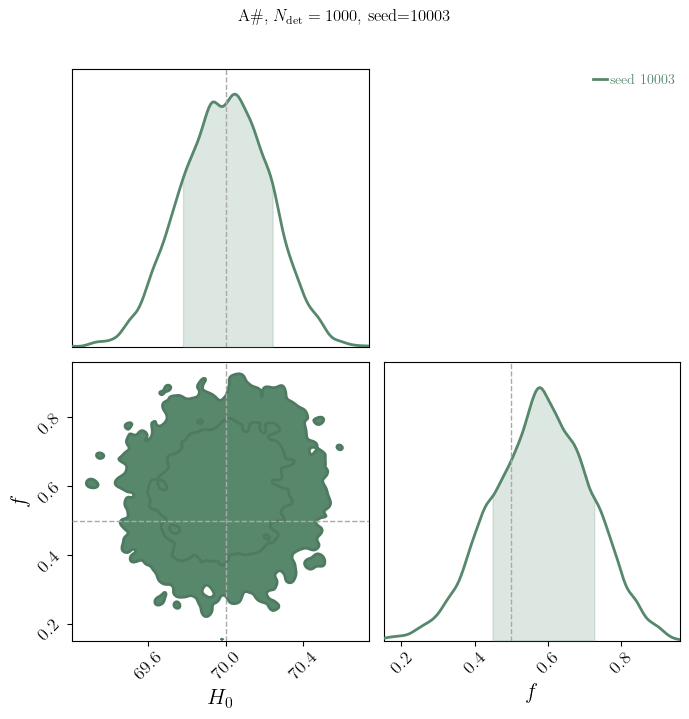

--------------------------------------------------------------------------------
Realisation 4, seed=10004
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_real4_seed10004_Final.pkl
seed=10004 H0=70.343 +0.208 -0.211 f=0.482 +0.141 -0.139


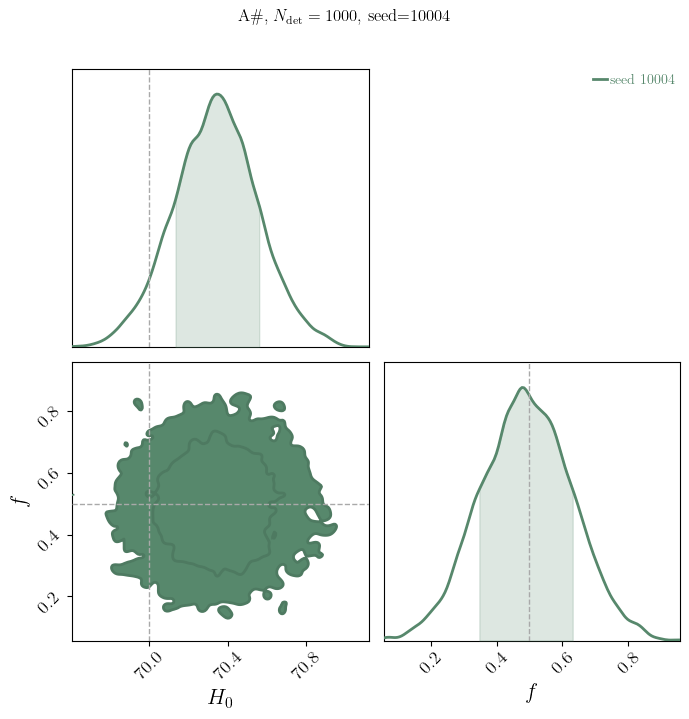

Parameter $H_0$ in chain seed 10005 is not constrained


--------------------------------------------------------------------------------
Realisation 5, seed=10005
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_real5_seed10005_Final.pkl
seed=10005 H0=69.987 +0.173 -0.301 f=0.534 +0.146 -0.147


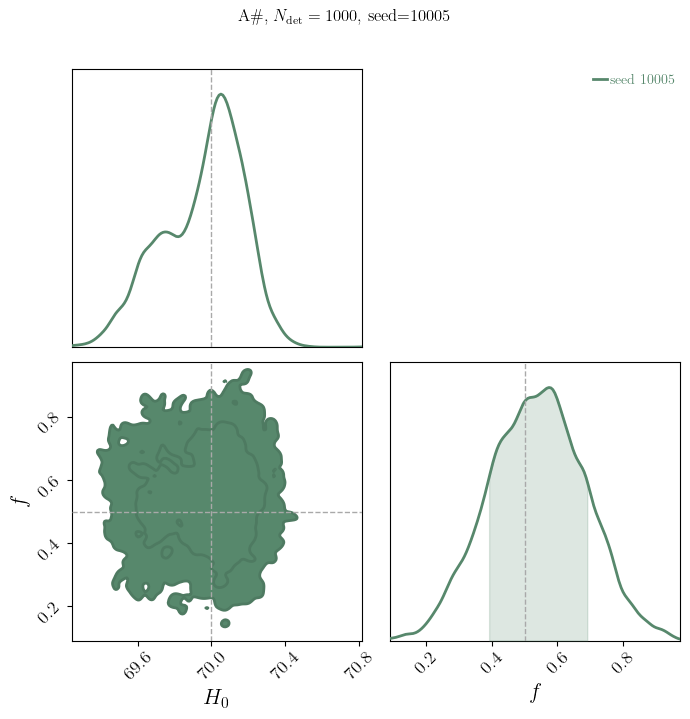

--------------------------------------------------------------------------------
Realisation 6, seed=10006
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_real6_seed10006_Final.pkl
seed=10006 H0=69.815 +0.147 -0.139 f=0.465 +0.138 -0.134


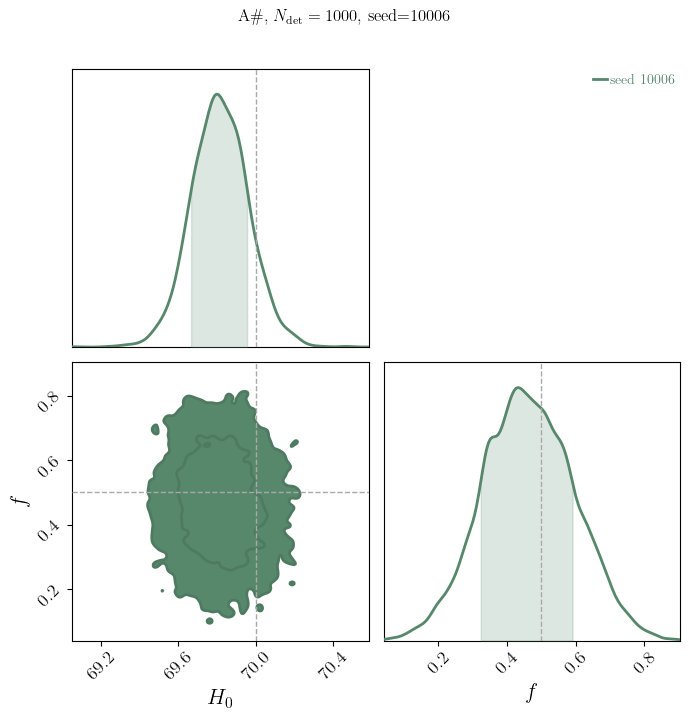

--------------------------------------------------------------------------------
Realisation 7, seed=10007
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_real7_seed10007_Final.pkl
seed=10007 H0=70.085 +0.195 -0.190 f=0.391 +0.141 -0.135


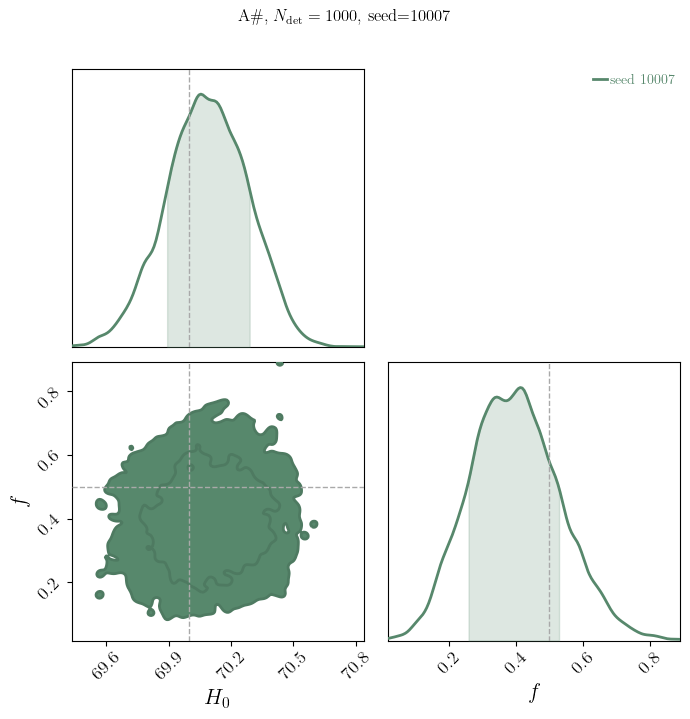

Parameter $H_0$ in chain seed 10008 is not constrained


--------------------------------------------------------------------------------
Realisation 8, seed=10008
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_real8_seed10008_Final.pkl
seed=10008 H0=69.801 +0.420 -0.142 f=0.370 +0.151 -0.147


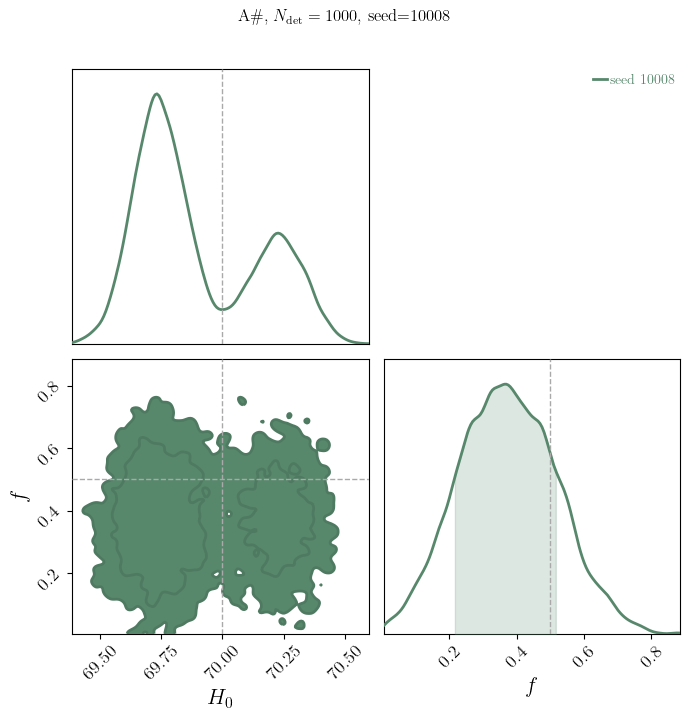

--------------------------------------------------------------------------------
Realisation 9, seed=10009
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_real9_seed10009_Final.pkl
seed=10009 H0=69.809 +0.172 -0.150 f=0.434 +0.131 -0.120


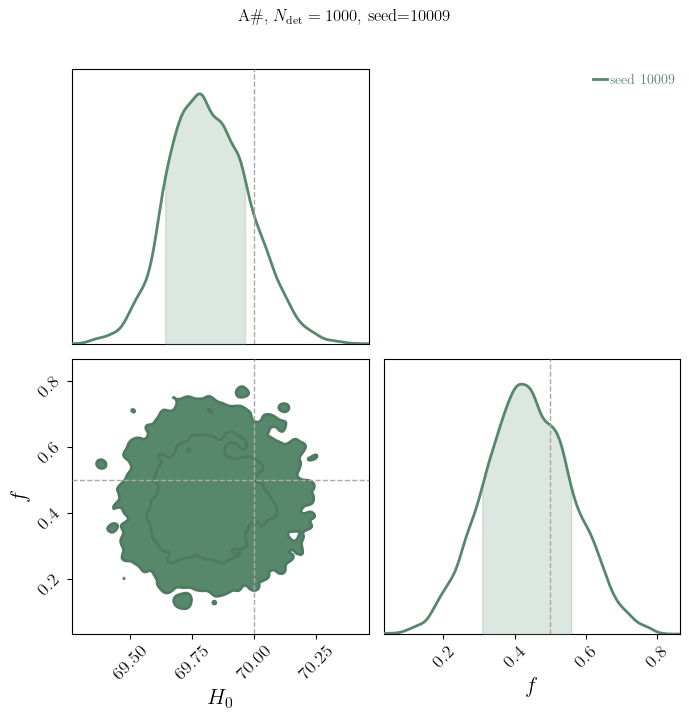

Built 10 KDEs.
Loading existing averaged posterior: AveragePosterior_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_10reals_FINALAbsMagWeight.pkl
--------------------------------------------------------------------------------
AVERAGE H0 = 70.013 +0.198 -0.199
AVERAGE f  = 0.470 +0.141 -0.138

advanced Ndet=200
Loading prepared file: GWPrepared_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_10reals_FINALAbsMagWeight.pkl


Parameter $f$ in chain seed 10000 is not constrained


--------------------------------------------------------------------------------
Realisation 0, seed=10000
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_real0_seed10000_Final.pkl
seed=10000 H0=68.796 +1.581 -1.452 f=0.451 +0.352 -0.313


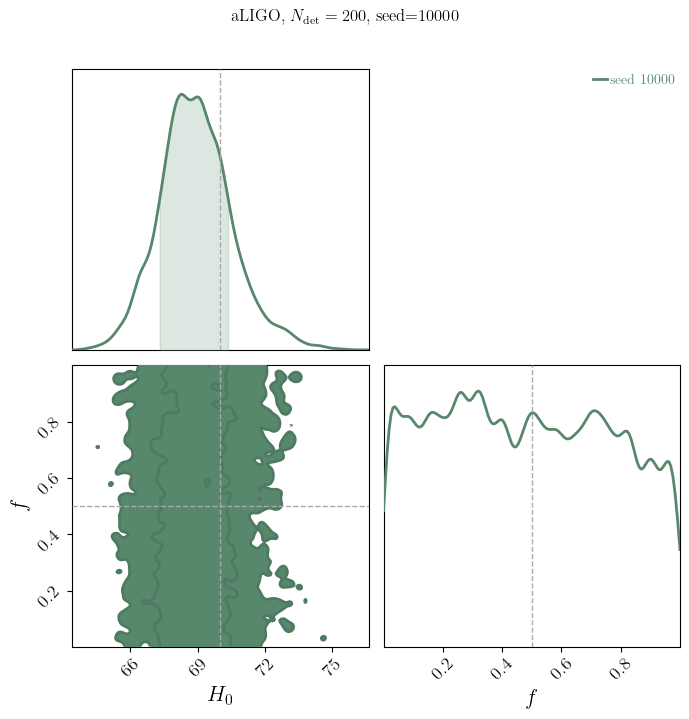

--------------------------------------------------------------------------------
Realisation 1, seed=10001
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_real1_seed10001_Final.pkl
seed=10001 H0=70.320 +1.635 -1.505 f=0.436 +0.359 -0.309


Parameter $f$ in chain seed 10001 is not constrained


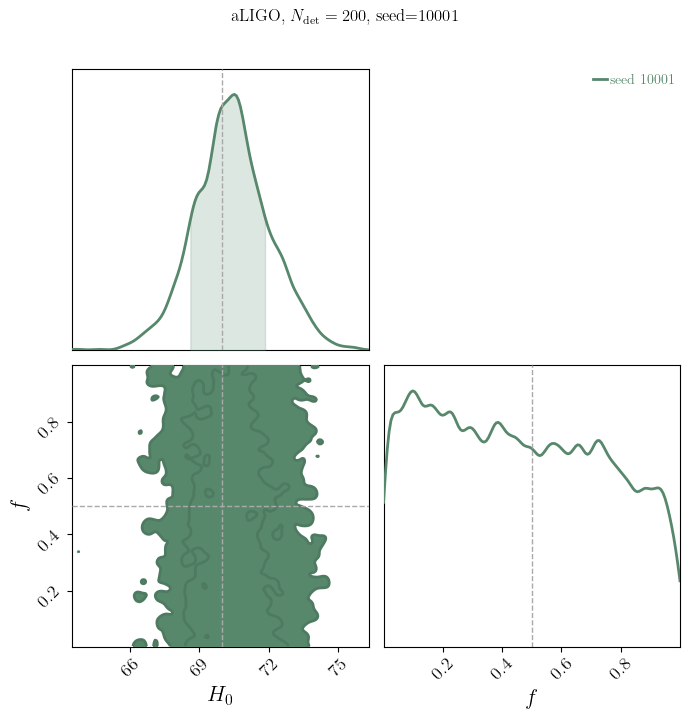

--------------------------------------------------------------------------------
Realisation 2, seed=10002
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_real2_seed10002_Final.pkl
seed=10002 H0=66.908 +1.492 -1.316 f=0.549 +0.303 -0.332


Parameter $f$ in chain seed 10002 is not constrained


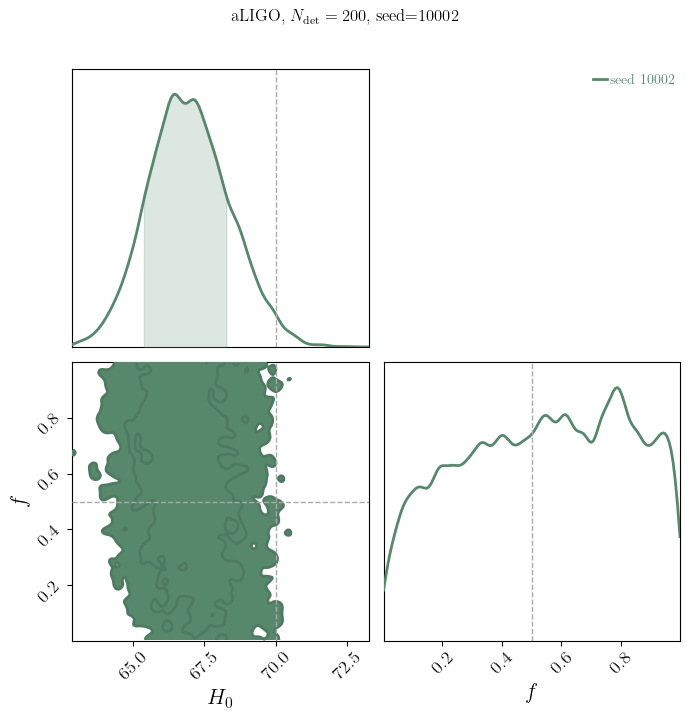

--------------------------------------------------------------------------------
Realisation 3, seed=10003
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_real3_seed10003_Final.pkl
seed=10003 H0=68.741 +1.314 -1.504 f=0.537 +0.317 -0.346


Parameter $f$ in chain seed 10003 is not constrained


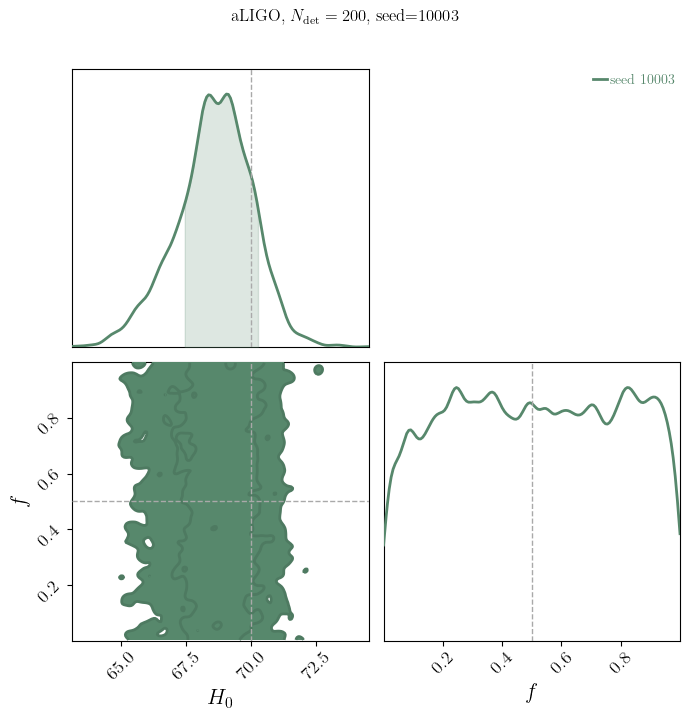

--------------------------------------------------------------------------------
Realisation 4, seed=10004
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_real4_seed10004_Final.pkl
seed=10004 H0=70.100 +0.994 -1.045 f=0.456 +0.349 -0.308


Parameter $f$ in chain seed 10004 is not constrained


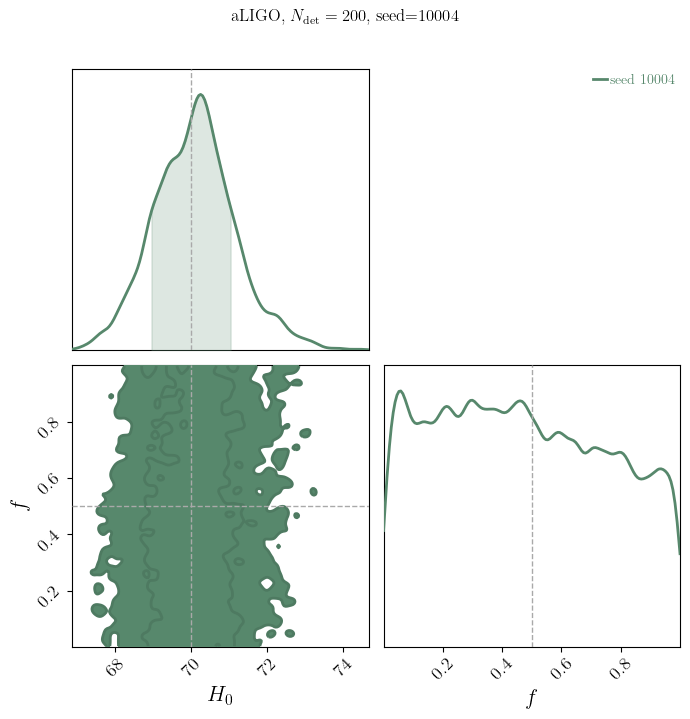

--------------------------------------------------------------------------------
Realisation 5, seed=10005
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_real5_seed10005_Final.pkl
seed=10005 H0=70.546 +1.189 -1.061 f=0.475 +0.303 -0.288


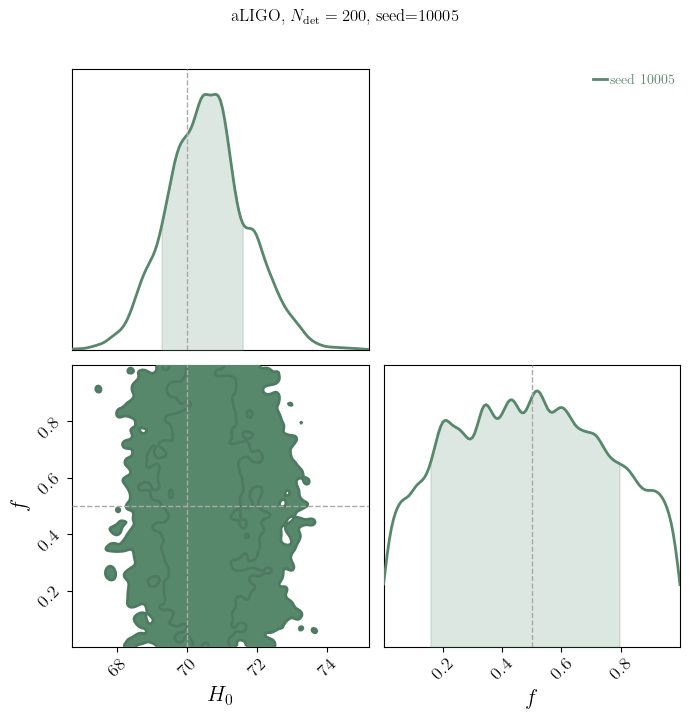

Parameter $H_0$ in chain seed 10006 is not constrained


--------------------------------------------------------------------------------
Realisation 6, seed=10006
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_real6_seed10006_Final.pkl
seed=10006 H0=70.319 +1.440 -1.345 f=0.630 +0.270 -0.362


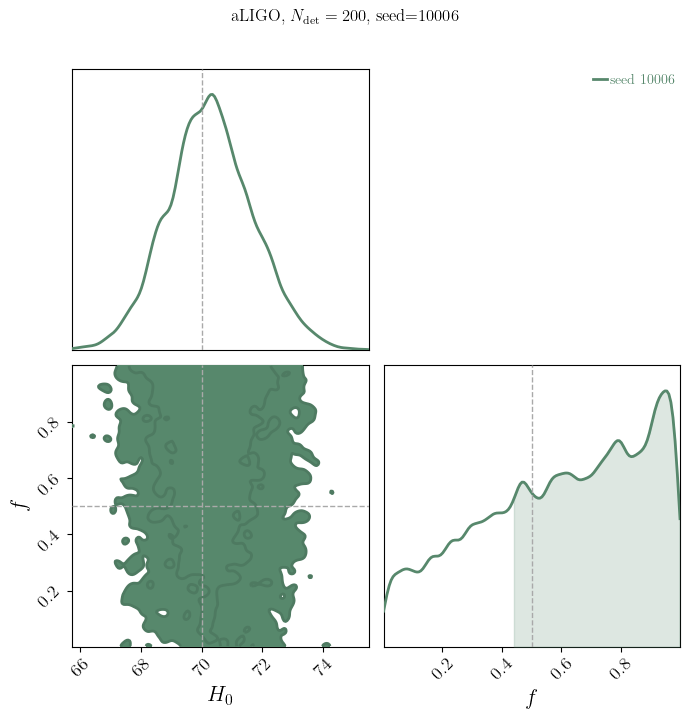

--------------------------------------------------------------------------------
Realisation 7, seed=10007
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_real7_seed10007_Final.pkl
seed=10007 H0=68.576 +1.849 -2.020 f=0.496 +0.337 -0.325


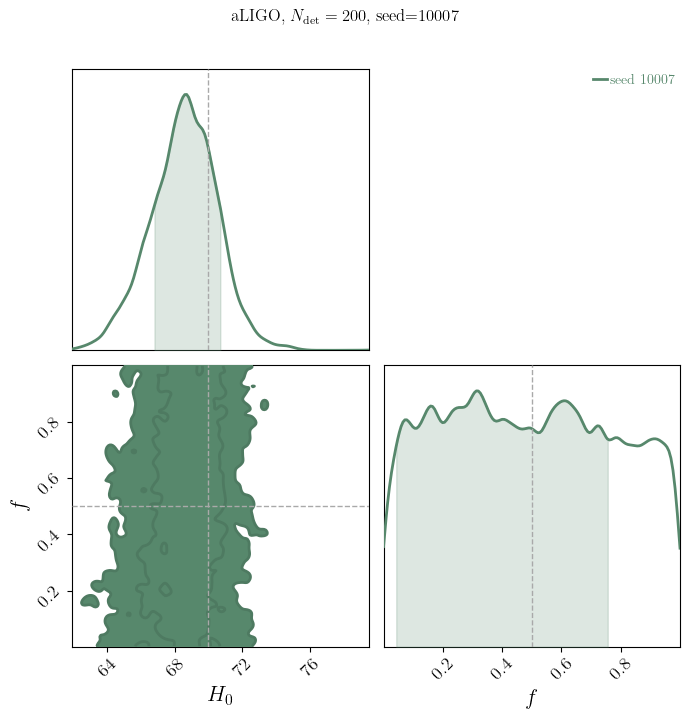

--------------------------------------------------------------------------------
Realisation 8, seed=10008
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_real8_seed10008_Final.pkl
seed=10008 H0=70.247 +1.642 -1.444 f=0.234 +0.317 -0.173


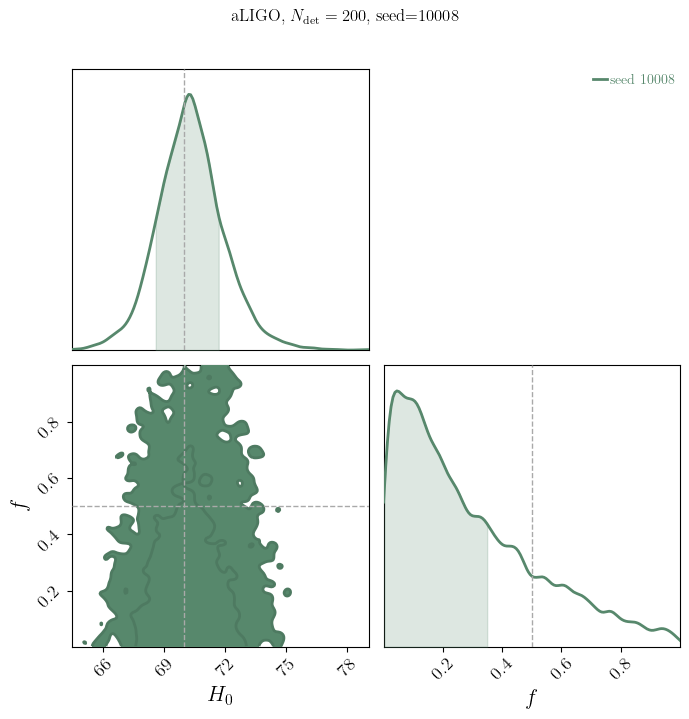

--------------------------------------------------------------------------------
Realisation 9, seed=10009
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_real9_seed10009_Final.pkl
seed=10009 H0=71.871 +1.685 -1.817 f=0.595 +0.285 -0.365


Parameter $f$ in chain seed 10009 is not constrained


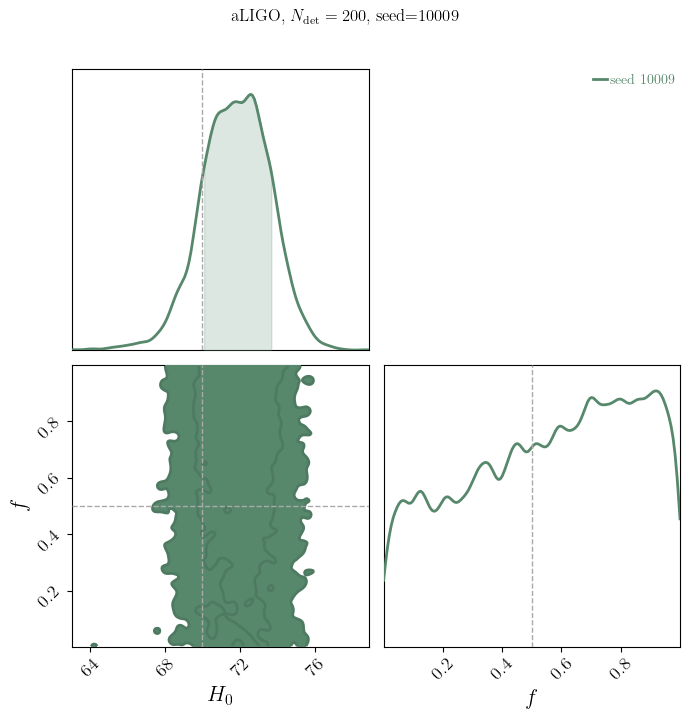

Built 10 KDEs.
Loading existing averaged posterior: AveragePosterior_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_10reals_FINALAbsMagWeight.pkl
--------------------------------------------------------------------------------
AVERAGE H0 = 69.737 +1.338 -1.394
AVERAGE f  = 0.470 +0.331 -0.300

asharp Ndet=200
Loading prepared file: GWPrepared_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_10reals_FINALAbsMagWeight.pkl


Parameter $f$ in chain seed 10000 is not constrained


--------------------------------------------------------------------------------
Realisation 0, seed=10000
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_real0_seed10000_Final.pkl
seed=10000 H0=70.109 +0.342 -0.343 f=0.550 +0.258 -0.257


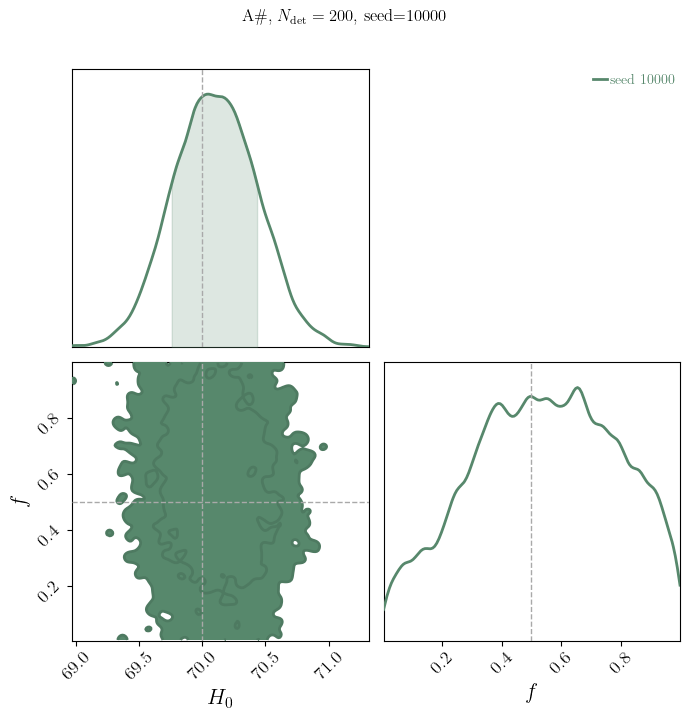

Parameter $f$ in chain seed 10001 is not constrained


--------------------------------------------------------------------------------
Realisation 1, seed=10001
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_real1_seed10001_Final.pkl
seed=10001 H0=70.610 +0.479 -0.486 f=0.621 +0.246 -0.300


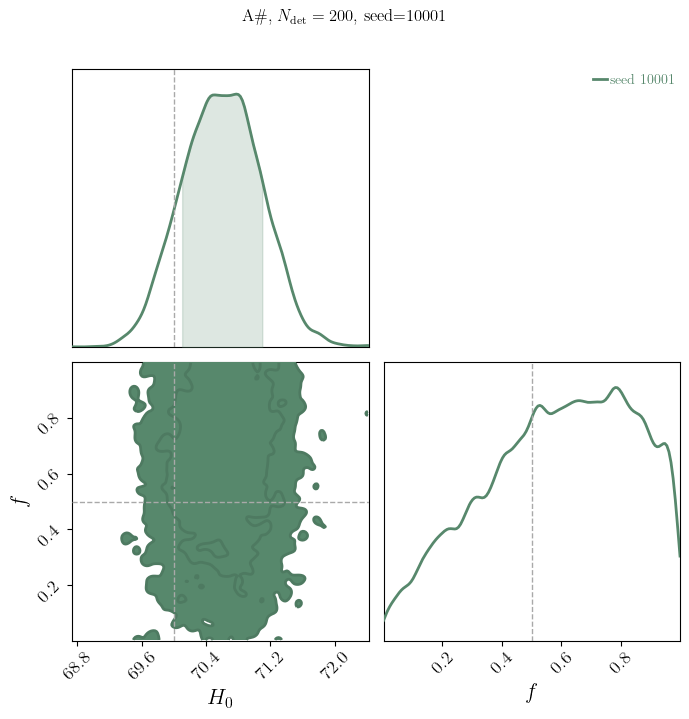

Parameter $f$ in chain seed 10002 is not constrained


--------------------------------------------------------------------------------
Realisation 2, seed=10002
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_real2_seed10002_Final.pkl
seed=10002 H0=70.020 +0.489 -0.450 f=0.408 +0.321 -0.274


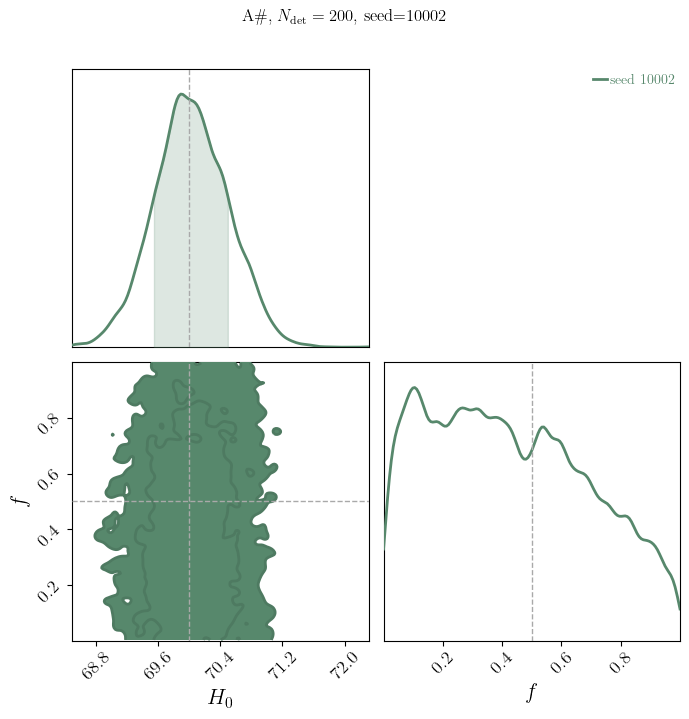

--------------------------------------------------------------------------------
Realisation 3, seed=10003
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_real3_seed10003_Final.pkl
seed=10003 H0=70.540 +0.527 -0.525 f=0.507 +0.258 -0.262


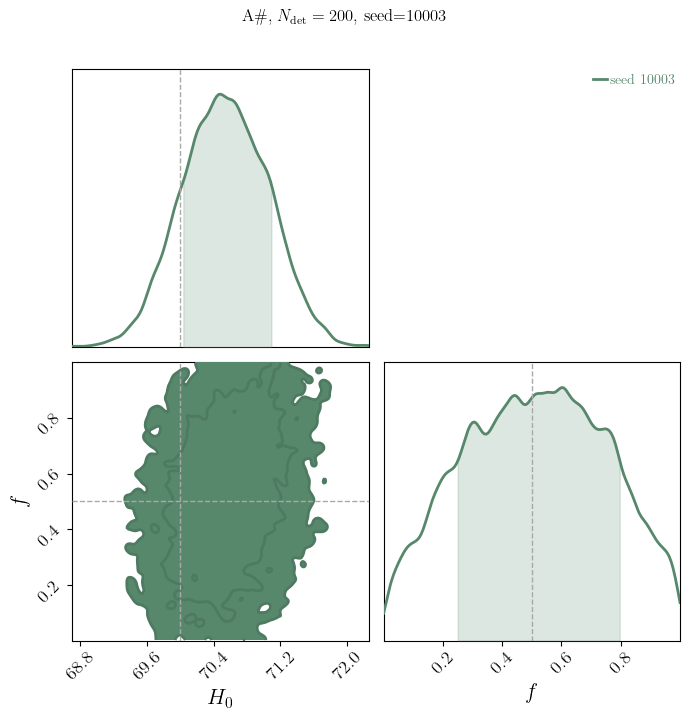

--------------------------------------------------------------------------------
Realisation 4, seed=10004
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_real4_seed10004_Final.pkl


Parameter $f$ in chain seed 10004 is not constrained


seed=10004 H0=70.560 +0.400 -0.384 f=0.313 +0.273 -0.203


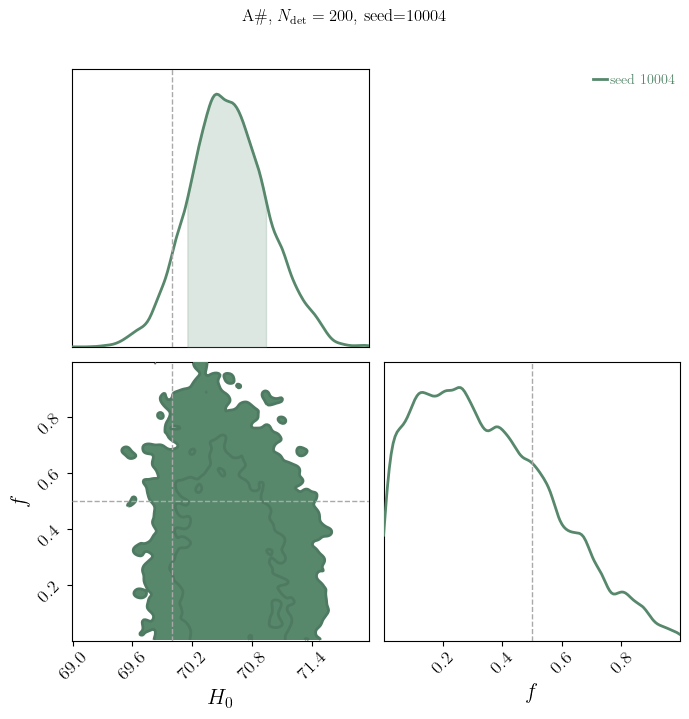

--------------------------------------------------------------------------------
Realisation 5, seed=10005
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_real5_seed10005_Final.pkl


Parameter $H_0$ in chain seed 10005 is not constrained
Parameter $f$ in chain seed 10005 is not constrained


seed=10005 H0=70.394 +0.487 -0.241 f=0.328 +0.229 -0.177


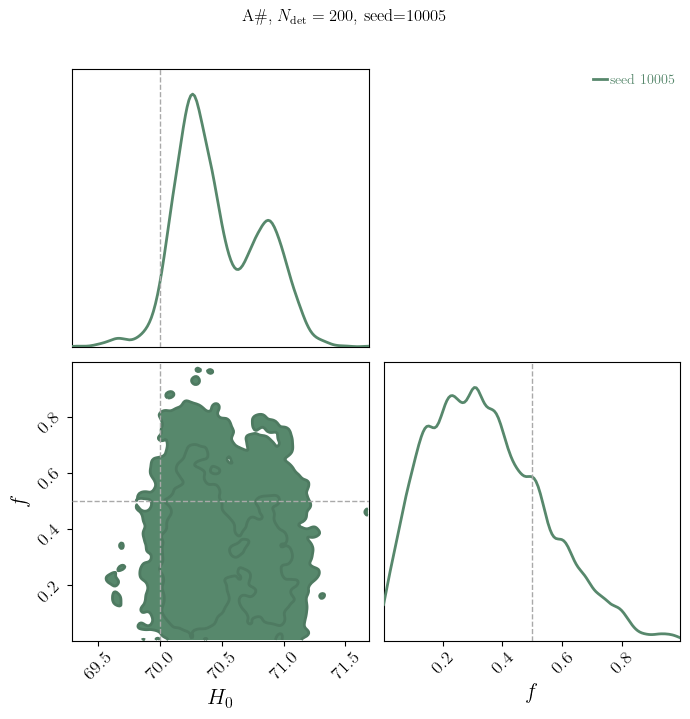

--------------------------------------------------------------------------------
Realisation 6, seed=10006
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_real6_seed10006_Final.pkl
seed=10006 H0=70.028 +0.570 -0.338 f=0.640 +0.210 -0.248


Parameter $H_0$ in chain seed 10006 is not constrained
Parameter $f$ in chain seed 10006 is not constrained


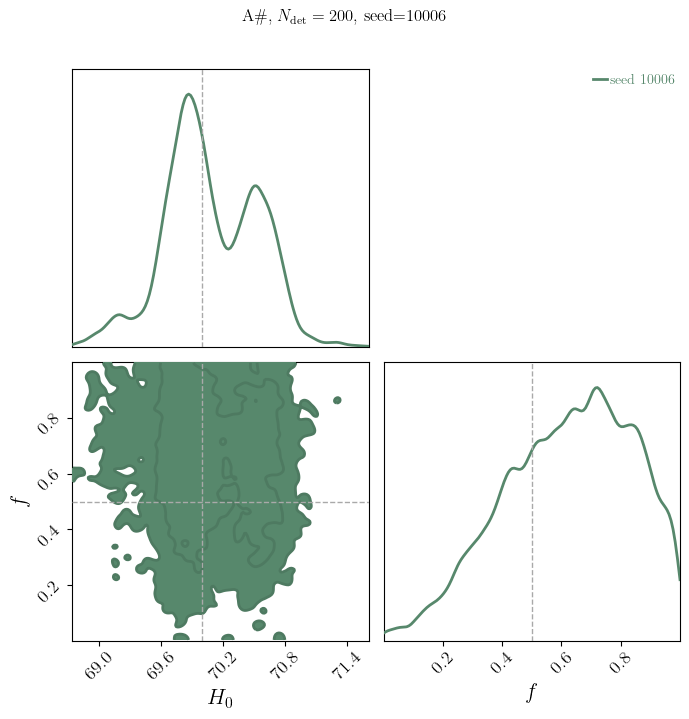

--------------------------------------------------------------------------------
Realisation 7, seed=10007
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_real7_seed10007_Final.pkl
seed=10007 H0=69.932 +0.443 -0.420 f=0.432 +0.318 -0.289


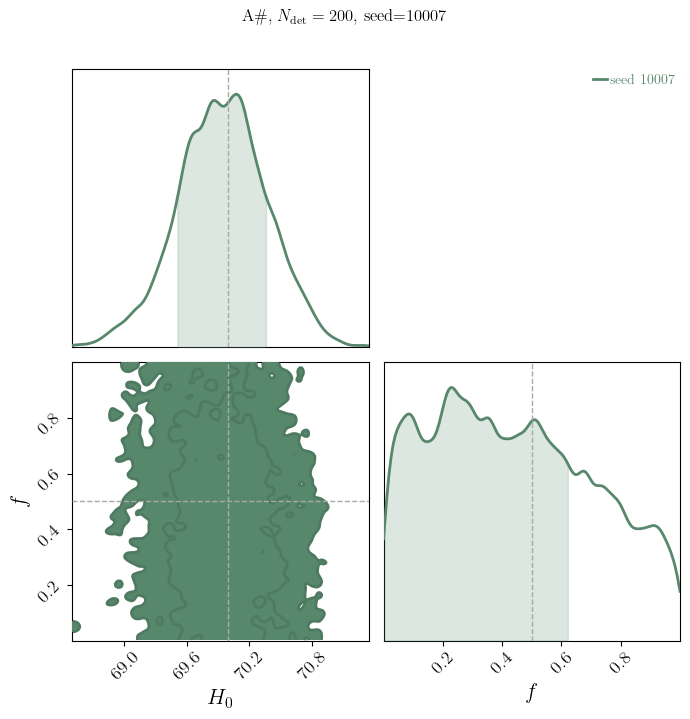

--------------------------------------------------------------------------------
Realisation 8, seed=10008
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_real8_seed10008_Final.pkl
seed=10008 H0=69.630 +0.354 -0.366 f=0.382 +0.247 -0.214


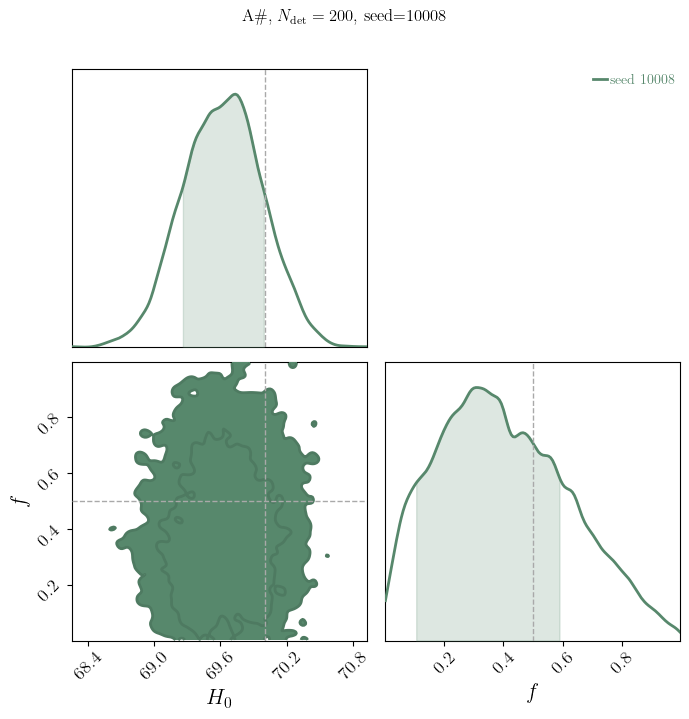

--------------------------------------------------------------------------------
Realisation 9, seed=10009
Loading existing KDE: LogKDE_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_real9_seed10009_Final.pkl


Parameter $f$ in chain seed 10009 is not constrained


seed=10009 H0=69.545 +0.382 -0.405 f=0.478 +0.252 -0.262


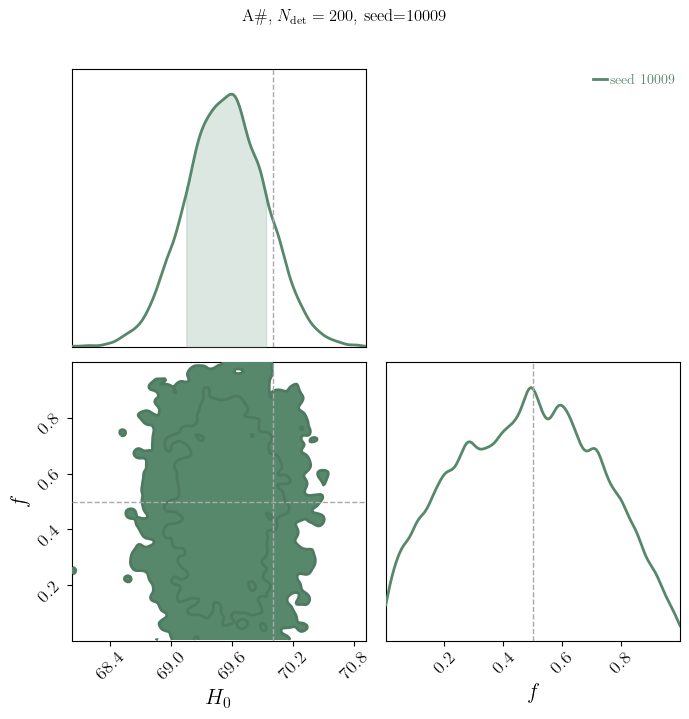

Built 10 KDEs.
Loading existing averaged posterior: AveragePosterior_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_10reals_FINALAbsMagWeight.pkl
--------------------------------------------------------------------------------
AVERAGE H0 = 70.131 +0.386 -0.387
AVERAGE f  = 0.466 +0.260 -0.251


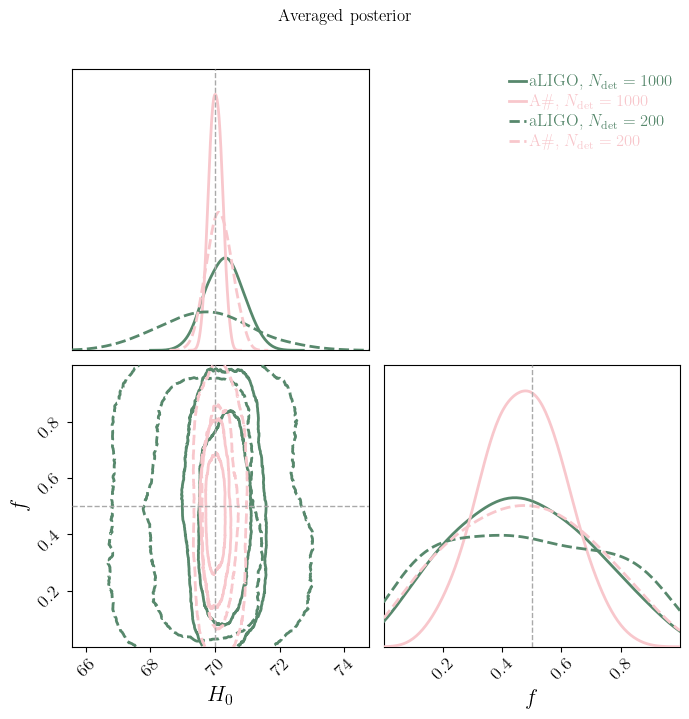

In [13]:
import os
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import emcee

from scipy.stats import gaussian_kde
from chainconsumer import ChainConsumer, Chain, Truth, PlotConfig

# ============================================================
# SETTINGS
# ============================================================
Ndets = [1000, 200]
network_names = ["advanced", "asharp"]

nreals = 10

H0_true = 70.0

ndim = 2

nwalkers_real = 12
nsteps_real = 5000
burnin_real = 500
thin_real = 1

nwalkers_average = 32
nsteps_average = 10000
burnin_average = 500
thin_average = 5

plot_thin = 10

H0_label = r"$H_0$"
f_label = r"$f$"
labels = [H0_label, f_label]

network_colors = {"asharp": "#f8c7cc", "advanced": "#57886c"}
network_labels = {"asharp": r"A\#", "advanced": "aLIGO"}
Ndet_linestyles = {200: "--", 1000: "-"}

all_average_samples = {}

# ============================================================
# MAIN CHAINCONSUMER OBJECT FOR AVERAGED POSTERIORS
# ============================================================
c_average_all = ChainConsumer()

# ============================================================
# LOOP THROUGH EACH NDET / NETWORK COMBINATION
# ============================================================
param_list = [(Ndet, network_name) for Ndet in Ndets for network_name in network_names]

for index, (Ndet, network_name) in enumerate(param_list):

    filename = f"GWPrepared_ftrue{f_true}_sigmaz{sigma_zi}_snr{snr_thr}_{network_name}_{Ndet}_{nreals}reals_FINALAbsMagWeight.pkl"

    print("\n" + "=" * 80)
    print(f"{network_name} Ndet={Ndet}")
    print("=" * 80)
    print(f"Loading prepared file: {filename}")

    if not os.path.exists(filename):
        print(f"Skipping missing file: {filename}")
        continue

    with open(filename, "rb") as f:
        results = pickle.load(f)

    shared_selection_catalogue = results[0]["selection_catalogue"]

    selection_model = build_paper_selection_model(
        data_MICECAT=data_MICECAT,
        selection_catalogue=shared_selection_catalogue,
        zcut_rate=0.7,
        H0_min=40.0,
        H0_max=100.0,
        nH0=241,
        nz_pdet=320,
    )
    shared_selection_catalogue = results[0]["selection_catalogue"]

    kdes = []
    all_realisation_samples = []

    data_rate_cut = data_MICECAT[data_MICECAT["z"] <= 0.7].copy()

    for r, res in enumerate(results):

        print("-" * 80)
        print(f"Realisation {r}, seed={res['seed']}")

        sigma_max_analysis = np.inf

        # ====================================================
        # KDE FILE NAME
        # ====================================================
        kde_filename = (
            f"LogKDE_ftrue{f_true}_sigmaz{sigma_zi}_snr{snr_thr}_{network_name}_{Ndet}_"
            f"real{r}_seed{res['seed']}_Final.pkl"
        )

        # ====================================================
        # LOAD EXISTING KDE/SAMPLES, OR PREP EVENTS + RUN MCMC
        # ====================================================
        if os.path.exists(kde_filename):

            print(f"Loading existing KDE: {kde_filename}")

            with open(kde_filename, "rb") as f:
                kde_data = pickle.load(f)

            kde = kde_data["kde"]
            flat_samples = np.asarray(kde_data["samples"], dtype=float)

            flat_samples = flat_samples[np.all(np.isfinite(flat_samples), axis=1)]

            if len(flat_samples) < 100:
                raise ValueError(
                    f"Too few valid saved samples for realisation {r}: {len(flat_samples)}"
                )

        else:

            print(f"No existing KDE found. Running MCMC for realisation {r}...")

            # ------------------------------------------------
            # Add local galaxy arrays if not already present
            # ------------------------------------------------
            if len(res["prepared_events"]) > 0 and "z_gal" not in res["prepared_events"][0]:
                print(f"Adding local galaxy arrays for realisation {r}...")

                for event in tqdm(res["prepared_events"]):
                    z_arr, F_r, F_gmr, sky_weight = prepare_mice_data(
                        data=data_rate_cut,
                        loc_area=event["loc_area"],
                        ra=event["ra"],
                        dec=event["dec"],
                        zcut_rate=None,
                    )

                    event["z_gal"] = z_arr
                    event["F_r_gal"] = F_r
                    event["F_gmr_gal"] = F_gmr
                    event["sky_weight"] = sky_weight

            # ------------------------------------------------
            # Make sure prepared events have SNR/amplitude info
            # ------------------------------------------------
            gw_snr = np.asarray(res["gw_catalogue"]["gw_snr"], dtype=float)
            gw_rho_times_dl = np.asarray(res["gw_catalogue"]["gw_rho_times_dl"], dtype=float)

            for ev in res["prepared_events"]:
                idx = int(ev["event_idx"])
                ev["gw_snr"] = gw_snr[idx]
                ev["rho_times_dl"] = gw_rho_times_dl[idx]

            N_use = len(clean_prepared_events(res["prepared_events"]))
            print(
                f"Using {N_use}/{len(res['prepared_events'])} events "
                f"with sigma_max={sigma_max_analysis}"
            )

            # ------------------------------------------------
            # Run MCMC
            # ------------------------------------------------
            sampler, flat_samples, flat_log_prob = run_H0_f_mcmc(
                prepared_events=res["prepared_events"],
                selection_catalogue=shared_selection_catalogue,
                sigma_max=sigma_max_analysis,
                H0_start=70,
                f_start=0.8,
                seed=res["seed"] + 54321,
                nwalkers=nwalkers_real,
                nsteps=nsteps_real,
                burnin=burnin_real,
                thin=thin_real,
            )

            flat_samples = np.asarray(flat_samples, dtype=float)
            flat_samples = flat_samples[np.all(np.isfinite(flat_samples), axis=1)]

            if len(flat_samples) < 100:
                raise ValueError(
                    f"Too few valid samples for realisation {r}: {len(flat_samples)}"
                )

            # ------------------------------------------------
            # Build and save KDE
            # ------------------------------------------------
            kde = gaussian_kde(flat_samples.T)

            with open(kde_filename, "wb") as f:
                pickle.dump(
                    {
                        "network_name": network_name,
                        "Ndet": Ndet,
                        "realisation": r,
                        "seed": res["seed"],
                        "f_true": f_true,
                        "H0_true": H0_true,
                        "sigma_max_analysis": sigma_max_analysis,
                        "labels": labels,
                        "kde": kde,
                        "samples": flat_samples,
                    },
                    f,
                )

            print(f"Saved individual KDE: {kde_filename}")

        # ====================================================
        # STORE KDE AND SAMPLES
        # ====================================================
        kdes.append(kde)
        all_realisation_samples.append(flat_samples)

        # ====================================================
        # PRINT REALISATION CONSTRAINT
        # ====================================================
        H0 = flat_samples[:, 0]
        f = flat_samples[:, 1]

        H0_q16, H0_q50, H0_q84 = np.percentile(H0, [16, 50, 84])
        f_q16, f_q50, f_q84 = np.percentile(f, [16, 50, 84])

        print(
            f"seed={res['seed']} "
            f"H0={H0_q50:.3f} +{H0_q84-H0_q50:.3f} -{H0_q50-H0_q16:.3f} "
            f"f={f_q50:.3f} +{f_q84-f_q50:.3f} -{f_q50-f_q16:.3f}"
        )

        # ====================================================
        # SINGLE CORNER PLOT FOR THIS REALISATION ONLY
        # ====================================================
        c_real = ChainConsumer()

        df_real = pd.DataFrame(flat_samples[::plot_thin], columns=labels)

        chain_real = Chain(
            samples=df_real,
            name=rf"seed {res['seed']}",
            color="#57886c",
            linewidth=2,
            linestyle="-",
            kde=False,
            shade=True,
            bar_shade=True,
            shade_gradient=0,
        )

        truth_real = Truth(
            location={H0_label: H0_true, f_label: f_true},
            color="#A9A9A9",
            line_style="--",
        )

        c_real.add_chain(chain_real)
        c_real.add_truth(truth_real)

        c_real.set_plot_config(
            PlotConfig(
                usetex=True,
                serif=True,
                plot_hists=True,
                summarise=False,
                show_legend=True,
                label_font_size=16,
                tick_font_size=13,
                legend_kwargs={"fontsize": 10, "frameon": False, "loc": "upper right"},
            )
        )

        fig = c_real.plotter.plot(columns=labels)
        plt.suptitle(
            rf"{network_labels[network_name]}, $N_{{\rm det}}={Ndet}$, seed={res['seed']}",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()
    print(f"Built {len(kdes)} KDEs.")
    # ========================================================
    # AVERAGED POSTERIOR FILE
    # ========================================================
    average_filename = (
        f"AveragePosterior_ftrue{f_true}_"
        f"sigmaz{sigma_zi}_snr{snr_thr}_"
        f"{network_name}_{Ndet}_{nreals}reals_"
        f"FINALAbsMagWeight.pkl"
    )

    # ========================================================
    # LOAD EXISTING AVERAGED POSTERIOR
    # ========================================================
    if os.path.exists(average_filename):

        print(f"Loading existing averaged posterior: {average_filename}")

        with open(average_filename, "rb") as f:
            average_data = pickle.load(f)

        average_samples = np.asarray(
            average_data["samples"],
            dtype=float,
        )

        average_samples = average_samples[
            np.all(np.isfinite(average_samples), axis=1)
        ]

        if average_samples.ndim != 2 or average_samples.shape[1] != ndim:
            raise ValueError(
                f"Unexpected averaged-sample shape in {average_filename}: "
                f"{average_samples.shape}; expected (Nsamples, {ndim})"
            )

        if len(average_samples) < 100:
            raise ValueError(
                f"Too few valid averaged samples in {average_filename}: "
                f"{len(average_samples)}"
            )

        average_log_prob = np.asarray(
            average_data.get(
                "log_prob",
                np.full(len(average_samples), np.nan),
            ),
            dtype=float,
        )

    # ========================================================
    # OTHERWISE BUILD THE AVERAGED POSTERIOR
    # ========================================================
    else:

        print(f"No averaged posterior found: {average_filename}")
        print("Building averaged posterior from realisation KDEs...")

        # ----------------------------------------------------
        # Geometric mean of the realisation KDE posteriors
        # ----------------------------------------------------
        def log_probability_average_kde(theta):
            H0, f = theta

            if not 40.0 <= H0 <= 100.0:
                return -np.inf

            if not 0.0 <= f <= 1.0:
                return -np.inf

            point = np.array(
                [[H0], [f]],
                dtype=float,
            )

            logpdf_values = np.asarray(
                [
                    kde.logpdf(point)[0]
                    for kde in kdes
                ],
                dtype=float,
            )

            if not np.all(np.isfinite(logpdf_values)):
                return -np.inf

            return np.mean(logpdf_values)

        # ----------------------------------------------------
        # Sample the averaged posterior
        # ----------------------------------------------------
        rng = np.random.default_rng(1234 + index)

        initial_positions = np.zeros(
            (nwalkers_average, ndim),
            dtype=float,
        )

        initial_positions[:, 0] = rng.normal(
            loc=H0_true,
            scale=0.1,
            size=nwalkers_average,
        )

        initial_positions[:, 1] = rng.normal(
            loc=f_true,
            scale=0.005,
            size=nwalkers_average,
        )

        sampler_average = emcee.EnsembleSampler(
            nwalkers_average,
            ndim,
            log_probability_average_kde,
        )

        sampler_average.run_mcmc(
            initial_positions,
            nsteps_average,
            progress=True,
        )

        average_samples = sampler_average.get_chain(
            discard=burnin_average,
            thin=thin_average,
            flat=True,
        )

        average_log_prob = sampler_average.get_log_prob(
            discard=burnin_average,
            thin=thin_average,
            flat=True,
        )

        average_samples = np.asarray(
            average_samples,
            dtype=float,
        )

        average_log_prob = np.asarray(
            average_log_prob,
            dtype=float,
        )

        finite = (
            np.all(np.isfinite(average_samples), axis=1)
            & np.isfinite(average_log_prob)
        )

        average_samples = average_samples[finite]
        average_log_prob = average_log_prob[finite]

        if len(average_samples) < 100:
            raise ValueError(
                f"Too few valid averaged samples: {len(average_samples)}"
            )

        # ----------------------------------------------------
        # Calculate averaged constraints
        # ----------------------------------------------------
        H0_samples = average_samples[:, 0]
        f_samples = average_samples[:, 1]

        H0_med = np.median(H0_samples)
        H0_lo, H0_hi = np.percentile(
            H0_samples,
            [16, 84],
        )

        f_med = np.median(f_samples)
        f_lo, f_hi = np.percentile(
            f_samples,
            [16, 84],
        )

        average_kde = gaussian_kde(
            average_samples.T
        )

        # ----------------------------------------------------
        # Save averaged posterior
        # ----------------------------------------------------
        with open(average_filename, "wb") as f:
            pickle.dump(
                {
                    "network_name": network_name,
                    "Ndet": Ndet,
                    "nreals": nreals,
                    "f_true": f_true,
                    "H0_true": H0_true,
                    "sigma_zi": sigma_zi,
                    "snr_thr": snr_thr,
                    "labels": labels,
                    "samples": average_samples,
                    "log_prob": average_log_prob,
                    "kde": average_kde,
                    "constraints": {
                        "H0_median": H0_med,
                        "H0_q16": H0_lo,
                        "H0_q84": H0_hi,
                        "H0_plus": H0_hi - H0_med,
                        "H0_minus": H0_med - H0_lo,
                        "f_median": f_med,
                        "f_q16": f_lo,
                        "f_q84": f_hi,
                        "f_plus": f_hi - f_med,
                        "f_minus": f_med - f_lo,
                    },
                    "mcmc_settings": {
                        "nwalkers_average": nwalkers_average,
                        "nsteps_average": nsteps_average,
                        "burnin_average": burnin_average,
                        "thin_average": thin_average,
                    },
                },
                f,
            )

        print(f"Saved averaged posterior: {average_filename}")


    # ========================================================
    # STORE AND PRINT LOADED OR NEW AVERAGED POSTERIOR
    # ========================================================
    all_average_samples[(Ndet, network_name)] = average_samples

    H0_samples = average_samples[:, 0]
    f_samples = average_samples[:, 1]

    H0_med = np.median(H0_samples)
    H0_lo, H0_hi = np.percentile(
        H0_samples,
        [16, 84],
    )

    f_med = np.median(f_samples)
    f_lo, f_hi = np.percentile(
        f_samples,
        [16, 84],
    )

    print("-" * 80)
    print(
        f"AVERAGE H0 = {H0_med:.3f} "
        f"+{H0_hi-H0_med:.3f} "
        f"-{H0_med-H0_lo:.3f}"
    )
    print(
        f"AVERAGE f  = {f_med:.3f} "
        f"+{f_hi-f_med:.3f} "
        f"-{f_med-f_lo:.3f}"
    )
    # ========================================================
    # ADD AVERAGED POSTERIOR TO MAIN AVERAGE PLOT
    # ========================================================
    df_average = pd.DataFrame(average_samples[::plot_thin], columns=labels)

    chain_average = Chain(
        samples=df_average,
        name=rf"{network_labels[network_name]}, $N_{{\rm det}}={Ndet}$",
        color=network_colors[network_name],
        linewidth=2,
        linestyle=Ndet_linestyles[Ndet],
        kde=1,
        shade=False,
        bar_shade=False,
        shade_gradient=0,
    )

    c_average_all.add_chain(chain_average)

# ============================================================
# FINAL AVERAGED POSTERIOR PLOT
# ============================================================
truth_average = Truth(
    location={H0_label: H0_true, f_label: f_true},
    color="#A9A9A9",
    line_style="--",
)

c_average_all.add_truth(truth_average)

c_average_all.set_plot_config(
    PlotConfig(
        usetex=True,
        serif=True,
        plot_hists=True,
        summarise=False,
        show_legend=True,
        label_font_size=16,
        tick_font_size=13,
        legend_kwargs={"fontsize": 12, "frameon": False, "loc": "upper right"},
    )
)

fig = c_average_all.plotter.plot(columns=labels)
plt.suptitle("Averaged posterior", y=1.02)
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------
AveragePosterior_ftrue0.5_sigmaz0.001_snr8.0_advanced_1000_10reals_FINALAbsMagWeight.pkl
H0 = 70.300 +0.568 -0.579
f  = 0.469 +0.248 -0.240
--------------------------------------------------------------------------------
AveragePosterior_ftrue0.5_sigmaz0.001_snr8.0_advanced_200_10reals_FINALAbsMagWeight.pkl
H0 = 69.737 +1.338 -1.394
f  = 0.470 +0.331 -0.300
--------------------------------------------------------------------------------
AveragePosterior_ftrue0.5_sigmaz0.001_snr8.0_asharp_1000_10reals_FINALAbsMagWeight.pkl
H0 = 70.013 +0.198 -0.199
f  = 0.470 +0.141 -0.138
--------------------------------------------------------------------------------
AveragePosterior_ftrue0.5_sigmaz0.001_snr8.0_asharp_200_10reals_FINALAbsMagWeight.pkl
H0 = 70.131 +0.386 -0.387
f  = 0.466 +0.260 -0.251


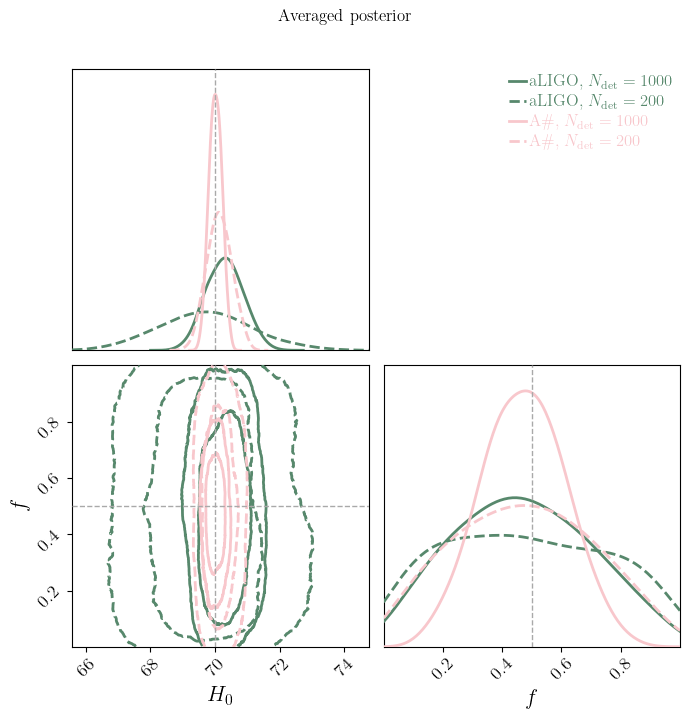

In [14]:
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chainconsumer import ChainConsumer, Chain, Truth, PlotConfig


# ============================================================
# SETTINGS
# ============================================================
snr_thr = 8.
pattern = f"AveragePosterior_ftrue0.5_sigmaz0.001_snr{snr_thr}_*_*_10reals_FINALAbsMagWeight.pkl"

plot_thin = 10

network_colors = {
    "asharp": "#f8c7cc",
    "advanced": "#57886c",
}

network_labels = {
    "asharp": r"A\#",
    "advanced": "aLIGO",
}

Ndet_linestyles = {
    200: "--",
    1000: "-",
}


# ============================================================
# LOAD AND PLOT
# ============================================================
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(f"No files matched pattern: {pattern}")

c = ChainConsumer()

H0_true = None
f_true = None
labels = None

for filename in files:
    with open(filename, "rb") as f:
        avg = pickle.load(f)

    average_samples = np.asarray(avg["samples"], dtype=float)
    average_samples = average_samples[np.all(np.isfinite(average_samples), axis=1)]

    labels = avg.get("labels", [r"$H_0$", r"$f$"])
    H0_label, f_label = labels

    H0_true = avg["H0_true"]
    f_true = avg["f_true"]

    network_name = avg["network_name"]
    Ndet = avg["Ndet"]

    df_average = pd.DataFrame(
        average_samples[::plot_thin],
        columns=labels,
    )

    chain_average = Chain(
        samples=df_average,
        name=rf"{network_labels.get(network_name, network_name)}, $N_{{\rm det}}={Ndet}$",
        color=network_colors.get(network_name, None),
        linewidth=2,
        linestyle=Ndet_linestyles.get(Ndet, "-"),
        kde=1,
        shade=False,
        bar_shade=False,
        shade_gradient=0,
    )

    c.add_chain(chain_average)

    cons = avg["constraints"]
    print("-" * 80)
    print(filename)
    print(
        f"H0 = {cons['H0_median']:.3f} "
        f"+{cons['H0_plus']:.3f} "
        f"-{cons['H0_minus']:.3f}"
    )
    print(
        f"f  = {cons['f_median']:.3f} "
        f"+{cons['f_plus']:.3f} "
        f"-{cons['f_minus']:.3f}"
    )


# ============================================================
# ADD TRUTH AND FORMAT
# ============================================================
truth = Truth(
    location={labels[0]: H0_true, labels[1]: f_true},
    color="#A9A9A9",
    line_style="--",
)

c.add_truth(truth)

c.set_plot_config(
    PlotConfig(
        usetex=True,
        serif=True,
        plot_hists=True,
        summarise=False,
        show_legend=True,
        label_font_size=16,
        tick_font_size=13,
        legend_kwargs={
            "fontsize": 12,
            "frameon": False,
            "loc": "upper right",
        },
    )
)

fig = c.plotter.plot(columns=labels)
plt.suptitle("Averaged posterior", y=1.02)
plt.tight_layout()
plt.show()


--------------------------------------------------------------------------------
AveragePosterior_ftrue0.5_sigmaz0.001_snr11.0_advanced_1000_10reals_FINALAbsMagWeight.pkl
Network: aLIGO
Ndet:    1000
H0 = 69.435 +0.766 -0.406
f  = 0.381 +0.234 -0.193
--------------------------------------------------------------------------------
AveragePosterior_ftrue0.5_sigmaz0.001_snr11.0_advanced_200_10reals_FINALAbsMagWeight.pkl
Network: aLIGO
Ndet:    200
H0 = 69.911 +1.313 -1.311
f  = 0.596 +0.263 -0.330
--------------------------------------------------------------------------------
AveragePosterior_ftrue0.5_sigmaz0.001_snr11.0_asharp_1000_10reals_FINALAbsMagWeight.pkl
Network: A\#
Ndet:    1000
H0 = 70.048 +0.189 -0.192
f  = 0.440 +0.135 -0.130
--------------------------------------------------------------------------------
AveragePosterior_ftrue0.5_sigmaz0.001_snr11.0_asharp_200_10reals_FINALAbsMagWeight.pkl
Network: A\#
Ndet:    200
H0 = 70.119 +0.392 -0.414
f  = 0.448 +0.258 -0.243
--------

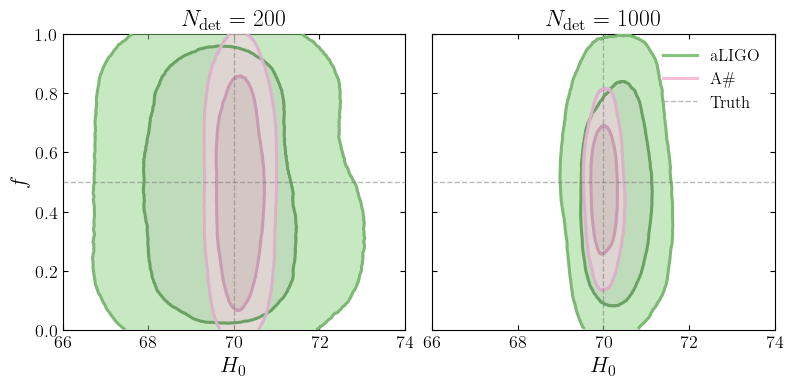

In [15]:
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from chainconsumer import Chain, Truth
from chainconsumer.plotting import plot_contour, plot_truths


# ============================================================
# SETTINGS
# ============================================================
pattern = (
    "AveragePosterior_ftrue0.5_sigmaz0.001_*_*_"
    "10reals_FINALAbsMagWeight.pkl"
)

plot_thin = 10

network_colors = {
    "advanced": "#85c47c",
    "asharp": "#f5bdd7",
}

network_labels = {
    "advanced": "aLIGO",
    "asharp": r"A\#",
}

network_order = ["advanced", "asharp"]

Ndet_values = [200, 1000]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14,
})


# ============================================================
# LOAD CHAINS
# ============================================================
files = sorted(glob.glob(pattern))

if len(files) == 0:
    raise FileNotFoundError(
        f"No files matched pattern:\n{pattern}"
    )

# chains_by_ndet[200] and chains_by_ndet[1000]
chains_by_ndet = {
    Ndet: {}
    for Ndet in Ndet_values
}

all_samples = []

labels = None
H0_true = None
f_true = None

for filename in files:
    with open(filename, "rb") as f:
        avg = pickle.load(f)

    network_name = avg["network_name"]
    Ndet = int(avg["Ndet"])

    # Ignore files outside the requested event counts/networks.
    if Ndet not in Ndet_values:
        continue

    if network_name not in network_order:
        continue

    average_samples = np.asarray(
        avg["samples"],
        dtype=float,
    )

    finite_mask = np.all(
        np.isfinite(average_samples),
        axis=1,
    )
    average_samples = average_samples[finite_mask]

    labels = avg.get(
        "labels",
        [r"$H_0$", r"$f$"],
    )

    H0_label, f_label = labels

    H0_true = float(avg["H0_true"])
    f_true = float(avg["f_true"])

    df_average = pd.DataFrame(
        average_samples[::plot_thin],
        columns=labels,
    )

    chain_average = Chain(
        samples=df_average,
        name=network_labels[network_name],
        color=network_colors[network_name],
        linewidth=2.2,
        linestyle="-",
        kde=1.5,
        shade=True,
        bar_shade=True,
        shade_gradient=0.2,
    )

    chains_by_ndet[Ndet][network_name] = chain_average
    all_samples.append(average_samples)

    cons = avg["constraints"]

    print("-" * 80)
    print(filename)
    print(f"Network: {network_labels[network_name]}")
    print(f"Ndet:    {Ndet}")
    print(
        f"H0 = {cons['H0_median']:.3f} "
        f"+{cons['H0_plus']:.3f} "
        f"-{cons['H0_minus']:.3f}"
    )
    print(
        f"f  = {cons['f_median']:.3f} "
        f"+{cons['f_plus']:.3f} "
        f"-{cons['f_minus']:.3f}"
    )


if labels is None:
    raise RuntimeError(
        "Files were found, but none matched the requested "
        "networks and event counts."
    )


# ============================================================
# COMMON AXIS LIMITS
# ============================================================
all_samples = np.vstack(all_samples)

H0_values = all_samples[:, 0]
f_values = all_samples[:, 1]

# Robust limits prevent a few extreme KDE samples from
# producing unnecessarily large plotting ranges.
H0_min, H0_max = np.percentile(
    H0_values,
    [0.1, 99.9],
)
f_min, f_max = np.percentile(
    f_values,
    [0.1, 99.9],
)

H0_padding = 0.08 * (H0_max - H0_min)
f_padding = 0.08 * (f_max - f_min)

""" H0_limits = (
    H0_min - H0_padding,
    H0_max + H0_padding,
) """
H0_limits = (66, 74)

f_limits = (
    max(0.0, f_min - f_padding),
    min(1.0, f_max + f_padding),
)


# ============================================================
# TRUTH
# ============================================================
truth = Truth(
    location={
        H0_label: H0_true,
        f_label: f_true,
    },
    color="#777777",
    line_style="--",
    line_width=1., 
    alpha=0.5
)


# ============================================================
# TWO CONTOUR-ONLY PANELS
# ============================================================
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8, 4),
    sharex=True,
    sharey=True,
)

for ax, Ndet in zip(axes, Ndet_values):

    for network_name in network_order:
        chain = chains_by_ndet[Ndet].get(network_name)

        if chain is None:
            print(
                f"Warning: no {network_name} chain found "
                f"for Ndet={Ndet}"
            )
            continue

        plot_contour(
            ax,
            chain,
            px=H0_label,
            py=f_label,
        )

    plot_truths(
        ax,
        [truth],
        px=H0_label,
        py=f_label,
    )

    ax.set_title(
        rf"$N_{{\rm det}}={Ndet}$",
        fontsize=17,
    )

    ax.set_xlabel(
        H0_label,
        fontsize=16,
    )

    ax.set_xlim(H0_limits)
    ax.set_ylim(f_limits)

    ax.tick_params(
        axis="both",
        labelsize=13,
        direction="in",
        top=True,
        right=True,
    )

axes[0].set_ylabel(
    f_label,
    fontsize=16,
)


# ============================================================
# LEGEND
# ============================================================
legend_handles = [
    Line2D(
        [0],
        [0],
        color=network_colors["advanced"],
        linewidth=2.2,
        linestyle="-",
        label=network_labels["advanced"],
    ),
    Line2D(
        [0],
        [0],
        color=network_colors["asharp"],
        linewidth=2.2,
        linestyle="-",
        label=network_labels["asharp"],
    ),
    Line2D(
        [0],
        [0],
        color="#777777",
        linewidth=1.,
        linestyle="--",
        label="Truth",alpha = 0.5
    ),
]

axes[1].legend(
    handles=legend_handles,
    fontsize=12,
    frameon=False,
    loc="upper right",
)


# ============================================================
# FINAL FORMATTING
# ============================================================
fig.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.16,
    top=0.90,
    wspace=0.08,
)

plt.show()

# Optional:
fig.savefig(
     "FinalPosteriors_ftrue0.5_snr8_asharp_advanced.png", dpi=300,
     bbox_inches="tight",
 )